# 📌 Submission Guidelines

### ✅ File Naming Rule  
Submit your notebook with the following format:

`StudentID_YourFullName_LABXX.ipynb`

or

`StudentID_YourFullName_LABXX.html`

**Examples (Correct):**
- `21113456_NguyenVanA_LAB01.ipynb`
- `19122233_TranThiB_LAB02.ipynb`

**Examples (Wrong → 0 points):**
- `Lab01.ipynb`
- `YourName.ipynb`
- `20123456.ipynb`
- `Lab01.pdf`

---

### 📌 Grading Policy

- ❌ Wrong filename format, missing submission, or plagiarism (code identical to others) → 0 points

- ⚠️ Submitting a file without results, incomplete work, or only the assignment description → Maximum 4 points

- ✅ Correct filename + Completed results → Graded normally based on assignment quality (accuracy, clarity, and originality)  
### Note:
- AI assistance is allowed, but you must write the code yourself. All submissions will be checked for originality.

---



## 🧪 NLP LAB  
### Attention Mechanism – From Bottleneck to Intelligent Representations

## TITLE

**Attention Mechanism Lab:** Understanding and Implementing Attention in Sequence Models

## LEARNING OBJECTIVES

After this lab session, students will:

### 🧠 Conceptual Understanding

- Understand the limitations of **fixed-size vector representations** (sequence → vector)
- Understand the **information bottleneck problem**
- Understand the core idea of the **Attention mechanism**
- Understand the roles of:
  - **Query**
  - **Key**
  - **Value**
- Understand why Attention improves model performance

### 💻 Practical Skills

Students will be able to:

- Build a sequence model **without Attention**
- Implement the **Attention mechanism step by step**
- Integrate Attention into an existing model
- Visualize **attention weights**

## 🎯 Intuition

### ❌ Without Attention


"I love deep learning very much" → Encoder → Prediction


👉 **Problem:**

- All information is compressed into one
- Leads to **information loss**, especially for long sequences

### ✅ With Attention


"I love deep learning very much" → Encoder outputs (multiple vectors) → Attention (focus on relevant parts) → Weighted combination → Prediction


👉 **Key Idea:**
> the model **selectively focuses on important parts of the sequence**.

## 💡 Takeaway

- Without Attention → **Information bottleneck**
- With Attention → **Dynamic, context-aware representation**

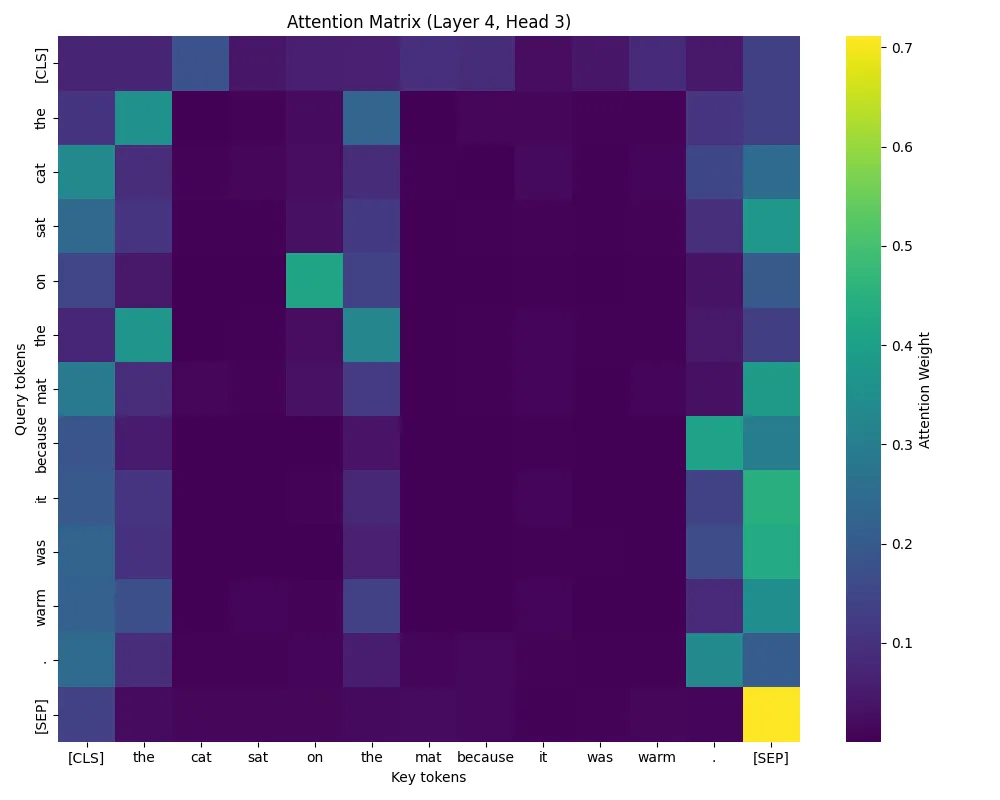

## SHORT THEORY (Detailed & Intuitive)

### Sequence-to-Vector Problem

Traditional **RNN/LSTM** models compress a sequence into a single vector:


$$\text{sequence} \rightarrow \mathbf{h}$$

Example: I love deep learning very much" → Encoder → h (single vector)


> ⚠️ Problem:
> - All information is forced into **one fixed-size vector**
> - Important details may be **lost**, especially in long sentences



### Bottleneck Problem

The vector $\mathbf{h}$ acts as a **bottleneck**:

- Limited capacity  
- Cannot store all information  

> ❗ The longer or more complex the sentence, the more severe the information loss.



### Core Idea of Attention

> 💡 Instead of compressing everything → **select relevant information dynamically**

At each step, the model:

- Looks at **all encoder outputs**
- Chooses what to focus on

### Query – Key – Value (Intuition)

| Component | Meaning | Example |
|----------|--------|--------|
| Query | What we are looking for | Current decoding step |
| Key | Representation of each word | Encoder hidden states |
| Value | Actual information | Same as key (often) |


### Step-by-Step Attention (Numerical Example)

Suppose we have 3 words → 3 vectors:

$$
K = [k_1, k_2, k_3], \quad V = [v_1, v_2, v_3]
$$

Query:

$$
q
$$

#### Step 1️⃣: Compute scores

Use dot product:

$$
score_i = q \cdot k_i
$$

Example:

$$
score = [2.0,\ 1.0,\ 0.1]
$$


#### Step 2️⃣: Apply Softmax
$$
weights = \text{softmax}(score)
$$

Result:

$$
weights \approx [0.65,\ 0.24,\ 0.11]
$$

> 💡 Higher score → higher attention weight

#### Step 3️⃣: Compute output

$$
output = \sum_i weight_i \cdot v_i
$$

$$
output = 0.65v_1 + 0.24v_2 + 0.11v_3
$$

> 🎯 The model focuses mostly on $v_i$

### Intuition Example (Sentence)

Sentence: "I love deep learning very much"

Task: predict next word

If the model focuses on:

- "learning" → high weight  
- "very" → medium weight  
- "I" → low weight  

→ Better prediction
### ✅ With Attention

Instead of using a single vector, the model keeps **all hidden states**:

\[
[h_1, h_2, h_3, ..., h_n]
\]

At prediction time, the model asks:

> 💡 "Which words should I focus on?"

### 🎯 Intuition Example

| Word | Importance | Attention Weight |
|------|----------|------------------|
| learning | Very important | 0.6 |
| very | Moderately important | 0.3 |
| I | Not important | 0.1 |

### 💡 Key Insight

- Not all words contribute equally  
- Attention assigns **dynamic importance weights**  
- The model focuses on **relevant information**

### 🚀 Why This Improves Prediction

To predict the next word (e.g., *"much"*):

- Focusing on **"learning" + "very"** → correct context  
- Ignoring irrelevant words → better accuracy  

### 🧠 Deep Understanding

> Attention is essentially a **weighted memory retrieval mechanism**

- The sequence = memory  
- Query = what we are looking for  
- Keys = indexing system  
- Values = actual stored information  


### 🔥 Final Takeaway

- Without Attention → **fixed representation + information bottleneck**
- With Attention → **dynamic, context-aware representation**

> ❗ Attention does not add new information  
> It **selects and re-weights existing information intelligently**


### Key Insight

- Attention assigns **importance weights** to each word  
- The model does **not treat all words equally**


### Summary

| Without Attention | With Attention |
|------------------|---------------|
| Single vector | Multiple vectors |
| Information loss | Selective focus |
| Fixed representation | Dynamic representation |


> 🚀 Attention allows models to **adaptively focus on relevant parts of the input**, solving the bottleneck problem.


# code sample

In [ ]:
!pip install datasets==2.18.0

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: C:\Users\quanp\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


## SIMPLE TOY DATASET

In [ ]:
from datasets import load_dataset

dataset = load_dataset("uitnlp/vietnamese_students_feedback")

In [ ]:
print(dataset["train"])

Dataset({
    features: ['sentence', 'sentiment', 'topic'],
    num_rows: 11426
})


In [ ]:
train_set = dataset["train"]
test_set = dataset["test"]

In [ ]:
def tokenize(text):
    return text.lower().split()

tokens_train = [tokenize(text) for text in train_set["sentence"]]
labels_train = train_set["sentiment"]


In [ ]:
from collections import Counter

counter = Counter()

for sentence in tokens_train:
    counter.update(sentence)

vocab = [w for w, c in counter.items() if c >= 2]
word2idx = {w:i+1 for i,w in enumerate(vocab)}  # +1 để dành cho padding
word2idx["<PAD>"] = 0

In [ ]:
max_len = 20

def encode(sentence):
    ids = [word2idx.get(w, 0) for w in sentence]
    ids = ids[:max_len]
    ids += [0] * (max_len - len(ids))
    return ids

data = [encode(s) for s in tokens_train]

In [ ]:
data[0]

[1, 2, 3, 4, 5, 6, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

In [ ]:
import torch

X = torch.tensor(data)
y = torch.tensor(labels_train)

In [ ]:
def predict(text,model):
    tok = tokenize(text)
    ids = encode(tok)
    x = torch.tensor([ids], dtype=torch.long)

    model.eval()

    out = model(x)
    pred = torch.argmax(out, dim=1).item()

    print("Text:", text)
    print("Prediction:", pred)

## BASELINE (NO ATTENTION)

In [ ]:
import torch
import torch.nn as nn

class SimpleModel(nn.Module):
    def __init__(self, vocab_size, embed_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.fc = nn.Linear(embed_dim, 3)

    def forward(self, x):
        emb = self.embedding(x)        # (seq_len, dim)
        pooled = emb.mean(dim=1)       # ❗ compress
        out = self.fc(pooled)
        return out

In [ ]:
model = SimpleModel(len(word2idx), 50)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 50
batch_size = 32

for epoch in range(epochs):
    total_loss = 0
    correct = 0

    for i in range(0, len(X), batch_size):
        xb = X[i:i+batch_size]
        yb = y[i:i+batch_size]

        out = model(xb)
        loss = criterion(out, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = out.argmax(dim=1)
        correct += (preds == yb).sum().item()

    acc = correct / len(X)

    print(f"Epoch {epoch} | Loss: {total_loss:.4f} | Acc: {acc:.4f}")

Epoch 0 | Loss: 283.8856 | Acc: 0.6604
Epoch 1 | Loss: 184.7141 | Acc: 0.8317
Epoch 2 | Loss: 147.3416 | Acc: 0.8650
Epoch 3 | Loss: 129.8724 | Acc: 0.8818
Epoch 4 | Loss: 119.4047 | Acc: 0.8917
Epoch 5 | Loss: 112.3355 | Acc: 0.8973
Epoch 6 | Loss: 107.1712 | Acc: 0.9019
Epoch 7 | Loss: 103.1773 | Acc: 0.9050
Epoch 8 | Loss: 99.9537 | Acc: 0.9096
Epoch 9 | Loss: 97.2659 | Acc: 0.9125
Epoch 10 | Loss: 94.9670 | Acc: 0.9139
Epoch 11 | Loss: 92.9593 | Acc: 0.9151
Epoch 12 | Loss: 91.1752 | Acc: 0.9166
Epoch 13 | Loss: 89.5665 | Acc: 0.9183
Epoch 14 | Loss: 88.0982 | Acc: 0.9199
Epoch 15 | Loss: 86.7446 | Acc: 0.9214
Epoch 16 | Loss: 85.4867 | Acc: 0.9220
Epoch 17 | Loss: 84.3100 | Acc: 0.9232
Epoch 18 | Loss: 83.2034 | Acc: 0.9244
Epoch 19 | Loss: 82.1585 | Acc: 0.9258
Epoch 20 | Loss: 81.1684 | Acc: 0.9262
Epoch 21 | Loss: 80.2277 | Acc: 0.9268
Epoch 22 | Loss: 79.3321 | Acc: 0.9276
Epoch 23 | Loss: 78.4778 | Acc: 0.9278
Epoch 24 | Loss: 77.6620 | Acc: 0.9288
Epoch 25 | Loss: 76.8820 | 

In [ ]:
predict("tôi thích học môn này",model)
predict("nó dở quá",model)
predict("môn học này rất hay",model)
predict("giảng viên dạy chán",model)

Text: tôi thích học môn này
Prediction: 1
Text: nó dở quá
Prediction: 0
Text: môn học này rất hay
Prediction: 2
Text: giảng viên dạy chán
Prediction: 0


## IMPLEMENT ATTENTION (CORE)

### Step 1: Compute scores

In [ ]:
def attention_scores(query, keys):
    # query: (batch_size, embed_dim)
    # keys: (batch_size, max_len, embed_dim)
    # For batched dot product: (B, S, D) @ (B, D, 1) -> (B, S, 1)
    return torch.bmm(keys, query.unsqueeze(-1)).squeeze(-1) # -> (batch_size, max_len)

### Step 2: Softmax

In [ ]:
def attention_weights(scores):
    # scores: (batch_size, max_len)
    # Apply softmax across max_len dimension for each batch item
    return torch.softmax(scores, dim=1)

### Step 3: Weighted sum

In [ ]:
def attention_output(weights, values):
    # weights: (batch_size, max_len)
    # values: (batch_size, max_len, embed_dim)
    # Unsqueeze weights to (batch_size, max_len, 1) for element-wise multiplication
    # Sum over max_len dimension (dim=1) to get (batch_size, embed_dim)
    return torch.sum(weights.unsqueeze(-1) * values, dim=1)

### combine

In [ ]:
def attention(query, keys, values):
    scores = attention_scores(query, keys)
    weights = attention_weights(scores)
    output = attention_output(weights, values)
    return output, weights

### Full model with attention

In [ ]:
class AttentionModel(nn.Module):
    def __init__(self, vocab_size, embed_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.fc = nn.Linear(embed_dim, 3) # Changed from 2 to 3 for 3 classes

    def forward(self, x):
        # x: (batch_size, max_len)
        emb = self.embedding(x)   # (batch_size, max_len, embed_dim)

        # Query should be per item in the batch, so average over max_len (dim=1)
        query = emb.mean(dim=1)   # (batch_size, embed_dim)

        output, weights = attention(query, emb, emb)

        out = self.fc(output) # output is (batch_size, embed_dim)
        return out, weights

### Training loop

In [ ]:
model = AttentionModel(len(word2idx), 50)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss()

epochs = 50
batch_size = 32

for epoch in range(epochs):
    total_loss = 0
    correct = 0

    for i in range(0, len(X), batch_size):
        xb = X[i:i+batch_size]
        yb = y[i:i+batch_size]

        out, _ = model(xb) # Unpack output and weights
        loss = criterion(out, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = out.argmax(dim=1)
        correct += (preds == yb).sum().item()

    acc = correct / len(X)

    print(f"Epoch {epoch} | Loss: {total_loss:.4f} | Acc: {acc:.4f}")

Epoch 0 | Loss: 274.5489 | Acc: 0.6068
Epoch 1 | Loss: 146.6322 | Acc: 0.8495
Epoch 2 | Loss: 100.8057 | Acc: 0.9072
Epoch 3 | Loss: 80.5677 | Acc: 0.9281
Epoch 4 | Loss: 65.4282 | Acc: 0.9450
Epoch 5 | Loss: 55.8635 | Acc: 0.9561
Epoch 6 | Loss: 48.8435 | Acc: 0.9644
Epoch 7 | Loss: 44.2559 | Acc: 0.9666
Epoch 8 | Loss: 40.2809 | Acc: 0.9693
Epoch 9 | Loss: 36.8208 | Acc: 0.9738
Epoch 10 | Loss: 33.6487 | Acc: 0.9755
Epoch 11 | Loss: 33.5509 | Acc: 0.9758
Epoch 12 | Loss: 31.8011 | Acc: 0.9759
Epoch 13 | Loss: 30.1886 | Acc: 0.9781
Epoch 14 | Loss: 27.1890 | Acc: 0.9802
Epoch 15 | Loss: 25.0731 | Acc: 0.9814
Epoch 16 | Loss: 25.0891 | Acc: 0.9823
Epoch 17 | Loss: 23.7095 | Acc: 0.9835
Epoch 18 | Loss: 23.4850 | Acc: 0.9838
Epoch 19 | Loss: 20.6871 | Acc: 0.9863
Epoch 20 | Loss: 21.1551 | Acc: 0.9861
Epoch 21 | Loss: 21.4618 | Acc: 0.9856
Epoch 22 | Loss: 21.9619 | Acc: 0.9851
Epoch 23 | Loss: 19.1915 | Acc: 0.9881
Epoch 24 | Loss: 17.1565 | Acc: 0.9886
Epoch 25 | Loss: 16.7254 | Acc: 

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt


def predict_attention_model(text,model):
    tok = tokenize(text)
    ids = encode(tok)
    x = torch.tensor([ids], dtype=torch.long)

    model.eval()

    out, weights = model(x)
    pred = torch.argmax(out, dim=1).item()

    print("Text:", text)
    print("Prediction:", pred)
    print("Attention weights:", weights)


    plt.figure(figsize=(10, 6)) # Set a larger figure size
    sns.heatmap(weights.detach(), annot=True)
    plt.show()
    print("===========================================")

Text: tôi thích học môn này
Prediction: 1
Attention weights: tensor([[8.6440e-01, 1.0333e-02, 4.0518e-03, 8.5284e-04, 4.6598e-05, 8.0208e-03,
         8.0208e-03, 8.0208e-03, 8.0208e-03, 8.0208e-03, 8.0208e-03, 8.0208e-03,
         8.0208e-03, 8.0208e-03, 8.0208e-03, 8.0208e-03, 8.0208e-03, 8.0208e-03,
         8.0208e-03, 8.0208e-03]], grad_fn=<SoftmaxBackward0>)


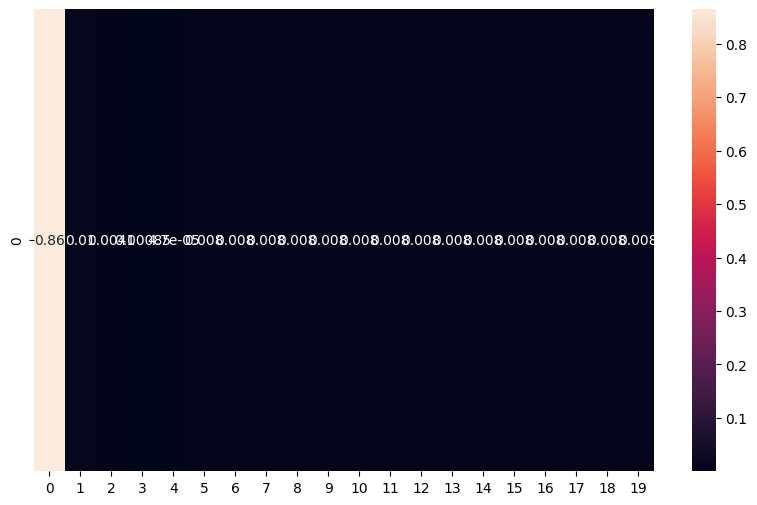

Text: nó dở quá
Prediction: 0
Attention weights: tensor([[2.0590e-08, 9.8192e-01, 1.3186e-02, 2.8757e-04, 2.8757e-04, 2.8757e-04,
         2.8757e-04, 2.8757e-04, 2.8757e-04, 2.8757e-04, 2.8757e-04, 2.8757e-04,
         2.8757e-04, 2.8757e-04, 2.8757e-04, 2.8757e-04, 2.8757e-04, 2.8757e-04,
         2.8757e-04, 2.8757e-04]], grad_fn=<SoftmaxBackward0>)


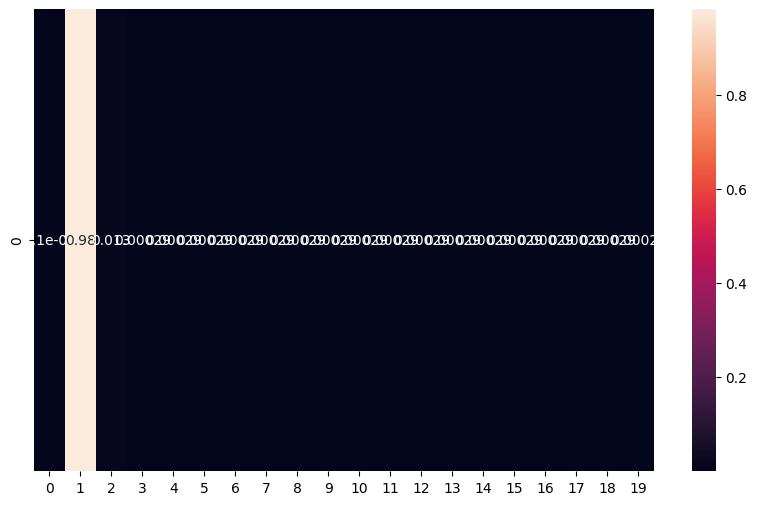

Text: môn học này rất hay
Prediction: 2
Attention weights: tensor([[2.7761e-06, 3.9949e-04, 1.0472e-03, 6.0445e-01, 3.8576e-01, 5.5560e-04,
         5.5560e-04, 5.5560e-04, 5.5560e-04, 5.5560e-04, 5.5560e-04, 5.5560e-04,
         5.5560e-04, 5.5560e-04, 5.5560e-04, 5.5560e-04, 5.5560e-04, 5.5560e-04,
         5.5560e-04, 5.5560e-04]], grad_fn=<SoftmaxBackward0>)


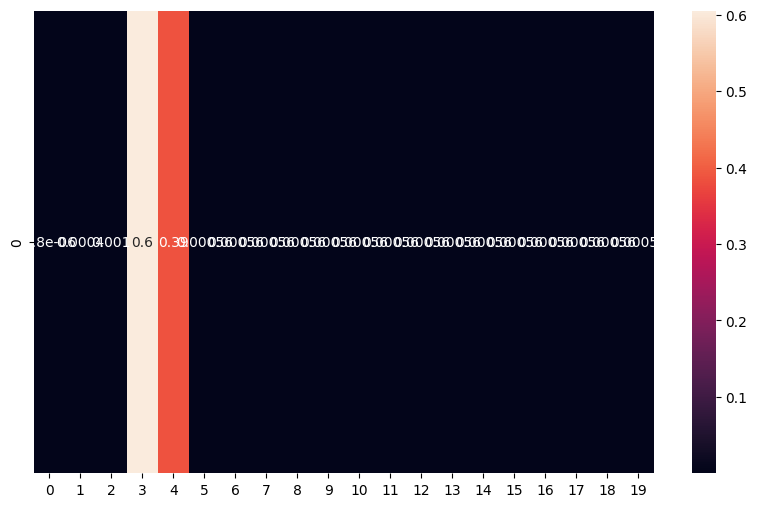

Text: giảng viên dạy chán
Prediction: 2
Attention weights: tensor([[0.0008, 0.0018, 0.2646, 0.0413, 0.0432, 0.0432, 0.0432, 0.0432, 0.0432,
         0.0432, 0.0432, 0.0432, 0.0432, 0.0432, 0.0432, 0.0432, 0.0432, 0.0432,
         0.0432, 0.0432]], grad_fn=<SoftmaxBackward0>)


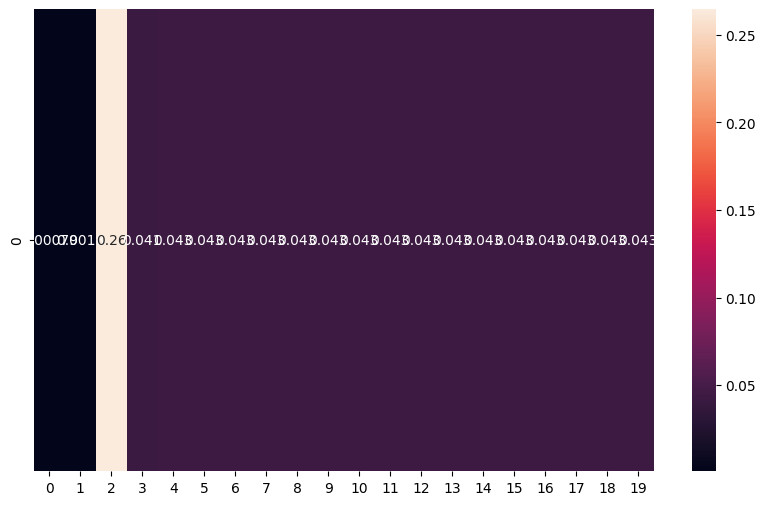

In [ ]:
predict_attention_model("tôi thích học môn này",model)
predict_attention_model("nó dở quá",model)
predict_attention_model("môn học này rất hay",model)
predict_attention_model("giảng viên dạy chán",model)

# Homework

## DISCUSSION QUESTIONS

1️⃣ Why does Attention improve model performance?

2️⃣ What happens if all attention weights are equal?

3️⃣ Why do we use the softmax function?

4️⃣ What are the roles of Query, Key, and Value?

5️⃣ Does Attention replace RNNs?

## 🧪 Experiments & Exercises

Overall Pipeline:

Data → Tokenization → Baseline Seq2Seq → Attention → Training → Evaluation → Visualization

### Dataset

We will use:

HuggingFace dataset: opus100 (en-vi)
```python
from datasets import load_dataset

dataset = load_dataset("opus100", "en-vi")
```

In [ ]:
dataset_homework = load_dataset("opus100", "en-vi")

NameError: name 'load_dataset' is not defined

In [ ]:
dataset_homework["test"][0]

{'translation': {'en': 'We are in a dive.', 'vi': 'Chúng ta đang lao xuống.'}}



### Part 1: Data Preprocessing

#### Requirements
- Inspect dataset
- Tokenization
  - Lowercase text
  - Split into tokens (use basic or torchtext/spacy)

- Build vocab for:
  - English (source)
  - Vietnamese (target)
  
  Include: \<pad>, \<sos>, \<eos>, \<unk>
  - CREATE padding_mask:
    mask = (input != \<pad>)
    

- Numericalization + Padding
  - Convert tokens → indices
  - Pad sequences to same length


- Analysis Questions
  - What happens when vocabulary size increases?
  - How does padding length affect training speed?
  - Why do we need \<sos> and \<eos>?

After processing (example)
  > encoder_input  = [\<sos>, i, love, you, \<eos>, \<pad>, ...]
  >
  > decoder_input  = [\<sos>, tôi, yêu, bạn, \<eos>, \<pad>, ...]
  >
  > target         = [tôi, yêu, bạn, \<eos>, \<pad>, ...]
  >
  > (target = decoder_input shifted left)

### Part 2: Baseline Model (NO Attention)
input_token → embedding → Encoder → final hidden → Decoder → output

```python
CLASS Seq2Seq:
    INIT(encoder, decoder):
        self.encoder = encoder
        self.decoder = decoder
    FORWARD(src, trg, teacher_forcing_ratio):
        hidden, cell = encoder(src)
        input_token = <sos>
        FOR t in range(1 → target_length):
            prediction, hidden, cell = decoder(input_token, hidden, cell)
            STORE prediction
            use_teacher = random() < teacher_forcing_ratio
            IF use_teacher:
                input_token = trg[t]
            ELSE:
                input_token = argmax(prediction)
        RETURN all_predictions
```

#### Requirements
- Implement a Seq2Seq model using LSTM (define 2 module)
  ``` using torch.nn.LSTM ```
  - Encoder (LSTM)
  - Decoder (LSTM)
  - Seq2Seq Wrapper
- Experiments
  - Change hidden size (128 → 512)
  - Change embedding size (100 → 300)
- Analysis Questions
  - Why does the baseline struggle with long sentences?
  - What information is lost in encoder hidden state?


### Part 3: Attention Mechanism
input_token → embedding → Encoder → all hidden states → Attention → Decoder → output

```python
CLASS Seq2SeqAttention:
    FORWARD(src, trg, teacher_forcing_ratio):
        encoder_outputs, hidden, cell = encoder(src)
        input_token = <sos>
        FOR t in range(1 → target_length):
            prediction, hidden, cell, attn = decoder(
                input_token, hidden, cell, encoder_outputs
            )
            STORE prediction
            STORE attention weights
            use_teacher = random() < teacher_forcing_ratio
            IF use_teacher:
                input_token = trg[t]
            ELSE:
                input_token = argmax(prediction)
        RETURN predictions, attention_weights
```

#### Requirements
- Define Attention Components
 - We implement Additive Attention (Bahdanau)
    - Step 1: Compute Attention Score
      - Query = Decoder hidden state
      - Key = Encoder outputs
      - Value = Encoder outputs
    - Compute Context Vector
  - Update Decoder: Decoder input = embedding + context_vector

- Experiments
  - Replace additive → dot-product attention


### Part 4: Training
#### Requirements
- Train:
  - Baseline model
  - Attention model

- Training Setup:
  - Use batching [batch_size, seq_len]
  - Use CrossEntropyLoss (ignore_index = \<pad>)
  - Optimizer (e.g., Adam)

- Logging:
  - Training loss
  - Validation loss

- Experiments:
  - Teacher forcing ratio: 0.5 vs 1.0
  - Learning rate changes

- Analysis Questions:
  - Which model converges faster and why?
  - Does attention improve generalization on long sequences?
  - How does teacher forcing ratio affect training stability?

### Part 5: Evaluation
#### Requirements
- Generate Translations
  ```python
  def translate_sentence(sentence, max_len):
    # encode → decode step-by-step
    ...
    return predicted_tokens
  
  ```
- Compare Outputs (2 models)
- Experiments
  - Try short vs long sentences
  - Try rare words
- Analysis Questions
  - Which model handles long sentences better and why?
  - How does attention help with rare or unknown words?
  - What types of errors does each model make?

### Part 6: Visualization (🔥 Important)
#### Requirements
- Visualize attention weights using heatmap
  - X-axis: source tokens
  - Y-axis: target tokens
  - Attention weights are normalized (softmax)

- Experiments:
  - Compare attention maps: good vs bad translations

- Analysis Questions:
  - Does attention align words correctly?
  - What patterns do you observe?
  - When does attention fail?

### Part 7: Shor Report
#### Requirements

Write a short report including:

1. Problem Description
   - Describe the translation task

2. Model Setup
   - Baseline vs Attention
   - Key hyperparameters

3. Experimental Results
   - Training & validation loss
   - Example translations

4. Attention Analysis
   - Visualization examples
   - Observations

5. Discussion
   - Strengths and weaknesses of each model
   - Common errors
   - Effect of teacher forcing

6. Conclusion
   - Key takeaways

# Homework
## Discussion questions

1️⃣ Why does Attention improve model performance?
It allows the model to selectively focus on the most relevant parts of the input data for every single step of the output. Instead of squashing an entire sentence into one fixed-size bottleneck (like older models did), attention creates direct shortcuts between words, making it much better at understanding long-range context and complex relationships.

2️⃣ What happens if all attention weights are equal?
The model simply takes a flat, unweighted average of all the input tokens. It completely loses its ability to "focus" on specific context, treating the most crucial word and a random punctuation mark as equally important. This effectively defeats the entire purpose of the attention mechanism.

3️⃣ Why do we use the softmax function?
Softmax converts the raw attention scores into a clean probability distribution. It forces the scores to fall between 0 and 1, and ensures they all sum up exactly to 1. This normalization acts like distributing 100% of the model's "focus" across the inputs, making the weights stable and interpretable.

4️⃣ What are the roles of Query, Key, and Value?
- Think of it like a search engine or database retrieval:
- Query: What the model is currently looking for or focusing on.
- Key: The "tags" or "labels" describing what information each input token holds.
- Value: The actual content or meaning of those input tokens.

How it works: The model calculates the similarity between the Query and all the Keys. High similarity means high attention weight, which tells the model to output more of that specific Value.

5️⃣ Does Attention replace RNNs?
Yes. Architectures that rely entirely on attention (like Transformers) process data in parallel rather than strictly sequentially word-by-word. This makes them significantly faster to train and far superior at handling long texts. While RNNs are still used in some highly specific, resource-constrained time-series tasks, Attention has become the dominant standard for modern AI.

## Experiments & Exercises

In [ ]:
from datasets import load_dataset
dataset_homework = load_dataset("opus100", "en-vi")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

en-vi/test-00000-of-00001.parquet:   0%|          | 0.00/137k [00:00<?, ?B/s]

en-vi/train-00000-of-00001.parquet:   0%|          | 0.00/59.0M [00:00<?, ?B/s]

en-vi/validation-00000-of-00001.parquet:   0%|          | 0.00/138k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/1000000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

### Part 1: Data preprocessing
#### Inspect dataset

In [ ]:
for i in range(10):
    print(dataset_homework["train"][i])

{'translation': {'en': 'What is it?', 'vi': 'Cái gì đó?'}}
{'translation': {'en': "I thought we would go to the children's home.", 'vi': 'Con nghĩ chúng ta nên đến mái ấm.'}}
{'translation': {'en': 'Is there something you want to tell your husband?', 'vi': 'Có điều gì cô muốn nói với chồng mình không?'}}
{'translation': {'en': 'Your master wants to hunt us, burn us, eat our hearts.', 'vi': 'Thầy của ngươi muốn săn chúng ta, thiêu chúng ta, ăn tim chúng ta.'}}
{'translation': {'en': 'Or too weak to see this through?', 'vi': 'Haylàkẻ yếuđuối?'}}
{'translation': {'en': 'OK.', 'vi': 'OK.'}}
{'translation': {'en': 'The rest are kept in a secure glass viewing boot at the top of the tower.', 'vi': 'Chỗ còn lại được để trong một lồng kính ngắm cảnh trên đỉnh toà nhà.'}}
{'translation': {'en': "No, I haven't.", 'vi': 'Không, tôi không có.'}}
{'translation': {'en': "Don't touch me.", 'vi': 'Đừng có chạm vào người tôi!'}}
{'translation': {'en': 'Come in.', 'vi': 'Xin mời.'}}


#### Tokenization

In [ ]:
from underthesea import word_tokenize
from torchtext.data.utils import get_tokenizer

tokenizer = get_tokenizer("basic_english")

def preprocess(example):
    text_en = example['translation']['en']
    text_vi = example['translation']['vi']

    ## preprocess english
    #Convert to lowercase
    text_en = text_en.lower()
    #Tokenize
    text_en = tokenizer(text_en)

    ## preprocess vietnamese
    #Convert to lowercase
    text_vi = text_vi.lower()
    #Tokenize
    text_vi = word_tokenize(text_vi)

    ## Change example
    example['translation']['en'] = text_en
    example['translation']['vi'] = text_vi

    return example

In [ ]:
processed_dataset = dataset_homework["train"].select(range(100000))

processed_dataset = processed_dataset.map(preprocess)

In [ ]:
for i in range(10):
    print(processed_dataset[i])

{'translation': {'en': ['what', 'is', 'it', '?'], 'vi': ['cái', 'gì', 'đó', '?']}}
{'translation': {'en': ['i', 'thought', 'we', 'would', 'go', 'to', 'the', 'children', "'", 's', 'home', '.'], 'vi': ['con', 'nghĩ', 'chúng ta', 'nên', 'đến', 'mái', 'ấm', '.']}}
{'translation': {'en': ['is', 'there', 'something', 'you', 'want', 'to', 'tell', 'your', 'husband', '?'], 'vi': ['có', 'điều', 'gì', 'cô', 'muốn', 'nói', 'với', 'chồng', 'mình', 'không', '?']}}
{'translation': {'en': ['your', 'master', 'wants', 'to', 'hunt', 'us', ',', 'burn', 'us', ',', 'eat', 'our', 'hearts', '.'], 'vi': ['thầy', 'của', 'ngươi', 'muốn', 'săn', 'chúng ta', ',', 'thiêu', 'chúng ta', ',', 'ăn', 'tim', 'chúng ta', '.']}}
{'translation': {'en': ['or', 'too', 'weak', 'to', 'see', 'this', 'through', '?'], 'vi': ['haylàkẻ', 'yếuđuối', '?']}}
{'translation': {'en': ['ok', '.'], 'vi': ['ok', '.']}}
{'translation': {'en': ['the', 'rest', 'are', 'kept', 'in', 'a', 'secure', 'glass', 'viewing', 'boot', 'at', 'the', 'top', '

#### Build vocab

In [5]:
from collections import Counter

word_counts_en = Counter()
word_counts_vi = Counter()

count = 0
for i in processed_dataset:
    # Lấy danh sách từ (tokens) từ chuỗi đã tokenize
    tokens_en = i['translation']['en']
    tokens_vi = i['translation']['vi']

    #cập nhập số lần mỗi từ xuất hiện với mỗi câu
    word_counts_en.update(tokens_en)
    word_counts_vi.update(tokens_vi)

    count += 1
    if count >= 100000:
        break

min_freq = 2

# Lọc số từ xuất hiện < 2
vocab_filtered_en = [word for word, count in word_counts_en.items() if count >= min_freq]
vocab_filtered_vi = [word for word, count in word_counts_vi.items() if count >= min_freq]

# Sort vocab theo tần suất giảm dần
vocab_en = sorted(vocab_filtered_en, key=lambda x: word_counts_en[x], reverse=True)
vocab_vi = sorted(vocab_filtered_vi, key=lambda x: word_counts_vi[x], reverse=True)

# Thêm <pad>, <sos>, <eos>, <unk>
SPECIAL_TOKENS = ['<pad>', '<sos>', '<eos>', '<unk>']
vocab_en = SPECIAL_TOKENS + vocab_en
vocab_vi = SPECIAL_TOKENS + vocab_vi

# Ánh xạ word và idx và ngược lại
word_to_idx_en = {word: i for i, word in enumerate(vocab_en)}
idx_to_word_en = {i: word for i, word in enumerate(vocab_en)}

word_to_idx_vi = {word: i for i, word in enumerate(vocab_vi)}
idx_to_word_vi = {i: word for i, word in enumerate(vocab_vi)}

In [3]:
print(len(vocab_en), len(vocab_vi))

14750 13209


#### Numericalization + Padding

In [6]:
def encode_en(sentence, word_to_idx_en, max_len = 20):
    PAD_IDX, SOS_IDX, EOS_IDX, UNK_IDX = 0, 1, 2, 3

    # Chuyển chữ thành số (nếu lạ thì gán là UNK_IDX)
    ids = [word_to_idx_en.get(w, UNK_IDX) for w in sentence]

    # Cắt bớt nếu câu quá dài, trừ 2 vị trí cho <sos> và <eos>
    ids = ids[:max_len - 2]

    # Thêm <sos> vào đầu và <eos> vào cuối
    ids = [SOS_IDX] + ids + [EOS_IDX]

    # Độn <pad> cho đủ max_len
    ids += [PAD_IDX] * (max_len - len(ids))
    return ids

def encode_vi(sentence, word_to_idx_vi, max_len = 20):
    PAD_IDX, SOS_IDX, EOS_IDX, UNK_IDX = 0, 1, 2, 3

    # Chuyển chữ thành số (nếu lạ thì gán là UNK_IDX)
    ids = [word_to_idx_vi.get(w, UNK_IDX) for w in sentence]

    # Cắt bớt nếu câu quá dài, trừ 2 vị trí cho <sos> và <eos>
    ids = ids[:max_len - 2]

    # Thêm <sos> vào đầu và <eos> vào cuối
    ids = [SOS_IDX] + ids + [EOS_IDX]

    # Độn <pad> cho đủ max_len
    ids += [PAD_IDX] * (max_len - len(ids))
    return ids

def encode(example):
    tokens_en = example['translation']['en']
    tokens_vi = example['translation']['vi']

    encoder_input = encode_en(tokens_en, word_to_idx_en)

    ids_vi = encode_vi(tokens_vi, word_to_idx_vi, max_len=21)
    decoder_input = ids_vi[:-1]
    target = ids_vi[1:]

    PAD_IDX = 0
    padding_mask_encoder = [1 if idx != PAD_IDX else 0 for idx in encoder_input]
    padding_mask_decoder = [1 if idx != PAD_IDX else 0 for idx in decoder_input]

    example['encoder_input'] = encoder_input
    example['encoder_mask'] = padding_mask_encoder
    example['decoder_input'] = decoder_input
    example['decoder_mask'] = padding_mask_decoder
    example['target'] = target

    return example

In [7]:
data = processed_dataset.map(encode, keep_in_memory=True)

Map:   0%|          | 0/100000 [00:00<?, ? examples/s]

In [ ]:
for i in range(2):
    print("i =", i)
    print(f"encoder_input: {data[i]['encoder_input']}")
    print(f"padding_mask_encoder: {data[i]['encoder_mask']}\n")

    print(f"decoder_input: {data[i]['decoder_input']}")
    print(f"padding_mask_decoder: {data[i]['decoder_mask']}\n")

    print(f"target: {data[i]['target']}\n")

i = 0
encoder_input: [1, 25, 21, 15, 10, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
padding_mask_encoder: [1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

decoder_input: [1, 46, 23, 17, 6, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
padding_mask_decoder: [1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

target: [46, 23, 17, 6, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

i = 1
encoder_input: [1, 8, 185, 22, 100, 55, 11, 9, 461, 6, 12, 178, 4, 2, 0, 0, 0, 0, 0, 0]
padding_mask_encoder: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0]

decoder_input: [1, 39, 79, 42, 117, 57, 1259, 1605, 4, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
padding_mask_decoder: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

target: [39, 79, 42, 117, 57, 1259, 1605, 4, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]



#### Analysis quesions
- **What happens when vocabulary size increases?**\
It helps the model understand more rare words (reducing <unk> tokens), but it drastically increases the size of the embedding and output layers. This consumes much more memory (RAM/VRAM) and significantly slows down both training and inference times.
- **How does padding length affect training speed?**\
A longer padding length (max sequence length) forces the model to process larger matrices. Because the self-attention mechanism's computational cost grows quadratically ($O(N^2)$) with sequence length, longer padding heavily increases memory usage and drastically slows down training speed.
- **Why do we need \<sos> and \<eos>?**\
They act as crucial "traffic signals" for the AI. <sos> (Start of Sequence) triggers the model's decoder to start predicting the very first word. <eos> (End of Sequence) tells the model that the sentence is complete, forcing it to stop generating words so it doesn't loop infinitely.

### Part 2: Baseline Model (NO Attention)
#### Implement a Seq2Seq

In [34]:
import torch
import torch.nn as nn
import random

class Encoder(nn.Module):
    def __init__(self, input_vocab_size, embedding_dim, hidden_dim, num_layers, dropout):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        self.embedding = nn.Embedding(input_vocab_size, embedding_dim)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, num_layers,
                            dropout=dropout, batch_first=True)

    def forward(self, src):
        embedded = self.embedding(src)

        outputs, (hidden, cell) = self.lstm(embedded)

        return hidden, cell

In [35]:
class Decoder(nn.Module):
    def __init__(self, output_vocab_size, embedding_dim, hidden_dim, num_layers, dropout):
        super().__init__()
        self.output_vocab_size = output_vocab_size
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        self.embedding = nn.Embedding(output_vocab_size, embedding_dim)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, num_layers,
                            dropout=dropout, batch_first=True)
        self.fc_out = nn.Linear(hidden_dim, output_vocab_size)

    def forward(self, input_token, hidden, cell):
        input_token = input_token.unsqueeze(1)

        embedded = self.embedding(input_token)

        output, (hidden, cell) = self.lstm(embedded, (hidden, cell))

        prediction = self.fc_out(output.squeeze(1))

        return prediction, hidden, cell

In [36]:
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, trg, teacher_forcing_ratio=0.5):
        batch_size = src.shape[0]
        trg_len = trg.shape[1]
        trg_vocab_size = self.decoder.output_vocab_size

        outputs = torch.zeros(batch_size, trg_len, trg_vocab_size).to(self.device)
        hidden, cell = self.encoder(src)

        input_token = trg[:, 0] # Token đầu tiên là <sos>

        # SỬA: Chạy từ 0 đến trg_len - 1
        for t in range(0, trg_len):
            prediction, hidden, cell = self.decoder(input_token, hidden, cell)

            # Lưu dự đoán vào đúng vị trí t
            outputs[:, t, :] = prediction

            use_teacher = random.random() < teacher_forcing_ratio

            # Cập nhật input_token cho bước tiếp theo (nếu chưa đến bước cuối)
            if t + 1 < trg_len:
                if use_teacher:
                    input_token = trg[:, t+1]
                else:
                    input_token = prediction.argmax(1)

        return outputs

Hàm thiết lập lại dataset để train

In [19]:
from torch.utils.data import Dataset, DataLoader

class TranslationDataset(Dataset):
    def __init__(self, hf_dataset):
        self.dataset = hf_dataset

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        item = self.dataset[idx]

        return {
            'encoder_input': torch.tensor(item['encoder_input'], dtype=torch.long),
            'decoder_input': torch.tensor(item['decoder_input'], dtype=torch.long),
            'target': torch.tensor(item['target'], dtype=torch.long)
        }

Thử nghiệm model với hidden size = 128 và ebedding size = 100

In [ ]:
device = torch.device("cuda")

data.reset_format()

pytorch_dataset = TranslationDataset(data)
train_loader = DataLoader(pytorch_dataset, batch_size=1024, shuffle=True, pin_memory=True)

INPUT_DIM = len(word_to_idx_en)
OUTPUT_DIM = len(word_to_idx_vi)
ENC_EMB_DIM = 100
DEC_EMB_DIM = 100
HID_DIM = 128
N_LAYERS = 2
ENC_DROPOUT = 0.5
DEC_DROPOUT = 0.5

enc = Encoder(INPUT_DIM, ENC_EMB_DIM, HID_DIM, N_LAYERS, ENC_DROPOUT)
dec = Decoder(OUTPUT_DIM, DEC_EMB_DIM, HID_DIM, N_LAYERS, DEC_DROPOUT)

In [ ]:
model = Seq2Seq(enc, dec, device).to(device)
model.train()

criterion = nn.CrossEntropyLoss(ignore_index=0)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 5

for epoch in range(epochs):
    total_loss = 0
    total_acc = 0

    for batch in train_loader:
        src = batch['encoder_input'].to(device)
        trg = batch['decoder_input'].to(device)
        gold = batch['target'].to(device)

        optimizer.zero_grad()
        output = model(src, trg)

        output_dim = output.shape[-1]
        output_flatten = output.view(-1, output_dim)
        gold_flatten = gold.view(-1)

        loss = criterion(output_flatten, gold_flatten)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = output_flatten.argmax(dim=1)
        non_pad_mask = (gold_flatten != 0)
        correct = (preds == gold_flatten) & non_pad_mask

        batch_acc = correct.sum().item() / non_pad_mask.sum().item()
        total_acc += batch_acc

    acc = total_acc / len(train_loader)

    print(f"Epoch {epoch} | Loss: {total_loss:.4f} | Acc: {acc:.4f}")

Epoch 0 | Loss: 619.0513 | Acc: 0.1185
Epoch 1 | Loss: 543.4669 | Acc: 0.1427
Epoch 2 | Loss: 535.0970 | Acc: 0.1582
Epoch 3 | Loss: 528.3547 | Acc: 0.1741
Epoch 4 | Loss: 521.5798 | Acc: 0.1850


Thử nghiệm model với hidden size = 512 và ebedding size = 100

In [ ]:
device = torch.device("cuda")

data.reset_format()

pytorch_dataset = TranslationDataset(data)
train_loader = DataLoader(pytorch_dataset, batch_size=1024, shuffle=True, pin_memory=True)

INPUT_DIM = len(word_to_idx_en)
OUTPUT_DIM = len(word_to_idx_vi)
ENC_EMB_DIM = 100
DEC_EMB_DIM = 100
HID_DIM = 512
N_LAYERS = 2
ENC_DROPOUT = 0.5
DEC_DROPOUT = 0.5

enc = Encoder(INPUT_DIM, ENC_EMB_DIM, HID_DIM, N_LAYERS, ENC_DROPOUT)
dec = Decoder(OUTPUT_DIM, DEC_EMB_DIM, HID_DIM, N_LAYERS, DEC_DROPOUT)

In [ ]:
model = Seq2Seq(enc, dec, device).to(device)
model.train()

criterion = nn.CrossEntropyLoss(ignore_index=0)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 5

for epoch in range(epochs):
    total_loss = 0
    total_acc = 0

    for batch in train_loader:
        src = batch['encoder_input'].to(device)
        trg = batch['decoder_input'].to(device)
        gold = batch['target'].to(device)

        optimizer.zero_grad()
        output = model(src, trg)

        output_dim = output.shape[-1]
        output_flatten = output.view(-1, output_dim)
        gold_flatten = gold.view(-1)

        loss = criterion(output_flatten, gold_flatten)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = output_flatten.argmax(dim=1)
        non_pad_mask = (gold_flatten != 0)
        correct = (preds == gold_flatten) & non_pad_mask

        batch_acc = correct.sum().item() / non_pad_mask.sum().item()
        total_acc += batch_acc

    acc = total_acc / len(train_loader)

    print(f"Epoch {epoch} | Loss: {total_loss:.4f} | Acc: {acc:.4f}")

Epoch 0 | Loss: 575.6605 | Acc: 0.1358
Epoch 1 | Loss: 535.9448 | Acc: 0.1701
Epoch 2 | Loss: 529.4045 | Acc: 0.1790
Epoch 3 | Loss: 521.6632 | Acc: 0.1891
Epoch 4 | Loss: 507.7530 | Acc: 0.2073


Thử nghiệm model với hidden size = 128 và ebedding size = 300

In [ ]:
device = torch.device("cuda")

data.reset_format()

pytorch_dataset = TranslationDataset(data)
train_loader = DataLoader(pytorch_dataset, batch_size=1024, shuffle=True, pin_memory=True)

INPUT_DIM = len(word_to_idx_en)
OUTPUT_DIM = len(word_to_idx_vi)
ENC_EMB_DIM = 300
DEC_EMB_DIM = 300
HID_DIM = 128
N_LAYERS = 2
ENC_DROPOUT = 0.5
DEC_DROPOUT = 0.5

enc = Encoder(INPUT_DIM, ENC_EMB_DIM, HID_DIM, N_LAYERS, ENC_DROPOUT)
dec = Decoder(OUTPUT_DIM, DEC_EMB_DIM, HID_DIM, N_LAYERS, DEC_DROPOUT)

In [ ]:
model = Seq2Seq(enc, dec, device).to(device)
model.train()

criterion = nn.CrossEntropyLoss(ignore_index=0)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 5

for epoch in range(epochs):
    total_loss = 0
    total_acc = 0

    for batch in train_loader:
        src = batch['encoder_input'].to(device)
        trg = batch['decoder_input'].to(device)
        gold = batch['target'].to(device)

        optimizer.zero_grad()
        output = model(src, trg)

        output_dim = output.shape[-1]
        output_flatten = output.view(-1, output_dim)
        gold_flatten = gold.view(-1)

        loss = criterion(output_flatten, gold_flatten)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = output_flatten.argmax(dim=1)
        non_pad_mask = (gold_flatten != 0)
        correct = (preds == gold_flatten) & non_pad_mask

        batch_acc = correct.sum().item() / non_pad_mask.sum().item()
        total_acc += batch_acc

    acc = total_acc / len(train_loader)

    print(f"Epoch {epoch} | Loss: {total_loss:.4f} | Acc: {acc:.4f}")

Epoch 0 | Loss: 614.2285 | Acc: 0.1174
Epoch 1 | Loss: 542.6289 | Acc: 0.1440
Epoch 2 | Loss: 535.6512 | Acc: 0.1519
Epoch 3 | Loss: 525.1993 | Acc: 0.1790
Epoch 4 | Loss: 515.0562 | Acc: 0.1955


Thử nghiệm model với hidden size = 512 và ebedding size = 300

In [ ]:
device = torch.device("cuda")

data.reset_format()

pytorch_dataset = TranslationDataset(data)
train_loader = DataLoader(pytorch_dataset, batch_size=1024, shuffle=True, pin_memory=True)

INPUT_DIM = len(word_to_idx_en)
OUTPUT_DIM = len(word_to_idx_vi)
ENC_EMB_DIM = 300
DEC_EMB_DIM = 300
HID_DIM = 512
N_LAYERS = 2
ENC_DROPOUT = 0.5
DEC_DROPOUT = 0.5

enc = Encoder(INPUT_DIM, ENC_EMB_DIM, HID_DIM, N_LAYERS, ENC_DROPOUT)
dec = Decoder(OUTPUT_DIM, DEC_EMB_DIM, HID_DIM, N_LAYERS, DEC_DROPOUT)

In [ ]:
model = Seq2Seq(enc, dec, device).to(device)
model.train()

criterion = nn.CrossEntropyLoss(ignore_index=0)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 5

for epoch in range(epochs):
    total_loss = 0
    total_acc = 0

    for batch in train_loader:
        src = batch['encoder_input'].to(device)
        trg = batch['decoder_input'].to(device)
        gold = batch['target'].to(device)

        optimizer.zero_grad()
        output = model(src, trg)

        output_dim = output.shape[-1]
        output_flatten = output.view(-1, output_dim)
        gold_flatten = gold.view(-1)

        loss = criterion(output_flatten, gold_flatten)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = output_flatten.argmax(dim=1)
        non_pad_mask = (gold_flatten != 0)
        correct = (preds == gold_flatten) & non_pad_mask

        batch_acc = correct.sum().item() / non_pad_mask.sum().item()
        total_acc += batch_acc

    acc = total_acc / len(train_loader)

    print(f"Epoch {epoch} | Loss: {total_loss:.4f} | Acc: {acc:.4f}")

Epoch 0 | Loss: 570.8442 | Acc: 0.1430
Epoch 1 | Loss: 532.8850 | Acc: 0.1784
Epoch 2 | Loss: 522.4570 | Acc: 0.1894
Epoch 3 | Loss: 508.4740 | Acc: 0.2065
Epoch 4 | Loss: 494.9178 | Acc: 0.2214


Sau thử nghiệm ta thấy model với hidden_size = 512 và embedding_size = 300 là tốt nhất nên ta sẽ chọn nó

- Why does the baseline struggle with long sentences?\
Baseline models face the information bottleneck. Forcing an entire 30 or 50-word sentence into a single fixed-size vector causes the model to "forget" the beginning of the sequence. This is also known as the vanishing gradient problem for long-range dependencies.
- What information is lost in encoder hidden state?\
The encoder's hidden state loses fine-grained temporal and local details. Because it acts as a general summary of the whole sentence, it cannot preserve the specific nuances of every individual word or the exact relationship between distant tokens. It lacks the ability to "point" back to specific input words during decoding (which is why Attention was later invented).

### Part 3: Attention mechanism
#### Thử nghiệm bằng Additive

In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import random

class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hid_dim, n_layers, dropout):
        super().__init__()
        self.embedding = nn.Embedding(input_dim, emb_dim)
        self.rnn = nn.LSTM(emb_dim, hid_dim, n_layers, dropout=dropout if n_layers > 1 else 0, batch_first=True)
        self.dropout = nn.Dropout(dropout)

    def forward(self, src):
        embedded = self.dropout(self.embedding(src))
        outputs, (hidden, cell) = self.rnn(embedded)
        return outputs, (hidden, cell)

In [9]:
class BahdanauAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.W_q = nn.Linear(hidden_dim, hidden_dim)
        self.W_k = nn.Linear(hidden_dim, hidden_dim)
        self.v = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, query, encoder_outputs):

        query = query.unsqueeze(1)

        energy = torch.tanh(self.W_q(query) + self.W_k(encoder_outputs))
        attention_scores = self.v(energy).squeeze(2)

        return F.softmax(attention_scores, dim=1)

In [10]:
class DecoderWithAttention(nn.Module):
    def __init__(self, output_dim, emb_dim, hidden_dim, dropout):
        super().__init__()
        self.output_dim = output_dim
        self.embedding = nn.Embedding(output_dim, emb_dim)

        self.attention = BahdanauAttention(hidden_dim)

        self.rnn = nn.LSTM(emb_dim + hidden_dim, hidden_dim, batch_first=True)
        self.fc_out = nn.Linear(emb_dim + hidden_dim * 2, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, input_token, hidden, cell, encoder_outputs):
        input_token = input_token.unsqueeze(1)
        embedded = self.dropout(self.embedding(input_token))

        query = hidden[-1]

        attn_weights = self.attention(query, encoder_outputs)
        attn_weights = attn_weights.unsqueeze(1)

        context_vector = torch.bmm(attn_weights, encoder_outputs)

        rnn_input = torch.cat((embedded, context_vector), dim=2)
        output, (hidden, cell) = self.rnn(rnn_input, (hidden, cell))

        prediction_input = torch.cat((output.squeeze(1), context_vector.squeeze(1), embedded.squeeze(1)), dim=1)
        prediction = self.fc_out(prediction_input)

        return prediction, hidden, cell, attn_weights.squeeze(1)

In [11]:
class Seq2SeqAttention(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, trg, teacher_forcing_ratio=0.5):
        batch_size = src.shape[0]
        target_length = trg.shape[1]
        target_vocab_size = self.decoder.output_dim

        predictions = torch.zeros(batch_size, target_length, target_vocab_size).to(self.device)
        attention_weights_list = torch.zeros(batch_size, target_length, src.shape[1]).to(self.device)

        encoder_outputs, (hidden, cell) = self.encoder(src)

        hidden = hidden[-1:]
        cell = cell[-1:]

        input_token = trg[:, 0]

        for t in range(0, target_length):
            prediction, hidden, cell, attn = self.decoder(
                input_token, hidden, cell, encoder_outputs
            )

            predictions[:, t] = prediction
            attention_weights_list[:, t] = attn

            use_teacher = random.random() < teacher_forcing_ratio

            if t + 1 < target_length:
                if use_teacher:
                    input_token = trg[:, t+1]
                else:
                    input_token = prediction.argmax(1)

        return predictions, attention_weights_list

In [ ]:
device = torch.device("cuda")

data.reset_format()

pytorch_dataset = TranslationDataset(data)
train_loader = DataLoader(pytorch_dataset, batch_size=1024, shuffle=True, pin_memory=True)

INPUT_DIM = len(word_to_idx_en)
OUTPUT_DIM = len(word_to_idx_vi)
ENC_EMB_DIM = 300
DEC_EMB_DIM = 300
HID_DIM = 512
N_LAYERS = 2
ENC_DROPOUT = 0.5
DEC_DROPOUT = 0.5

enc = Encoder(INPUT_DIM, ENC_EMB_DIM, HID_DIM, N_LAYERS, ENC_DROPOUT)
dec = DecoderWithAttention(OUTPUT_DIM, DEC_EMB_DIM, HID_DIM, DEC_DROPOUT)

In [ ]:
model = Seq2SeqAttention(enc, dec, device).to(device)
model.train()

criterion = nn.CrossEntropyLoss(ignore_index=0)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 5

for epoch in range(epochs):
    total_loss = 0
    total_acc = 0

    for batch in train_loader:
        src = batch['encoder_input'].to(device)
        trg = batch['decoder_input'].to(device)
        gold = batch['target'].to(device)

        optimizer.zero_grad()
        output, _ = model(src, trg)

        output_dim = output.shape[-1]
        output_flatten = output.view(-1, output_dim)
        gold_flatten = gold.view(-1)

        loss = criterion(output_flatten, gold_flatten)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = output_flatten.argmax(dim=1)
        non_pad_mask = (gold_flatten != 0)
        correct = (preds == gold_flatten) & non_pad_mask

        batch_acc = correct.sum().item() / non_pad_mask.sum().item()
        total_acc += batch_acc


    acc = total_acc / len(train_loader)

    print(f"Epoch {epoch} | Loss: {total_loss:.4f} | Acc: {acc:.4f}")

Epoch 0 | Loss: 558.2836 | Acc: 0.1637
Epoch 1 | Loss: 502.2221 | Acc: 0.2072
Epoch 2 | Loss: 473.8055 | Acc: 0.2396
Epoch 3 | Loss: 451.1873 | Acc: 0.2606
Epoch 4 | Loss: 431.8726 | Acc: 0.2765


#### Thử nghiệm bằng Dot-product attention

In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import random

class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hid_dim, n_layers, dropout):
        super().__init__()
        self.embedding = nn.Embedding(input_dim, emb_dim)
        self.rnn = nn.LSTM(emb_dim, hid_dim, n_layers, dropout=dropout if n_layers > 1 else 0, batch_first=True)
        self.dropout = nn.Dropout(dropout)

    def forward(self, src):
        embedded = self.dropout(self.embedding(src))
        outputs, (hidden, cell) = self.rnn(embedded)
        return outputs, (hidden, cell)

In [13]:
class DotProductAttention(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, query, encoder_outputs):

        query = query.unsqueeze(1)
        keys = encoder_outputs.transpose(1, 2)

        attention_scores = torch.bmm(query, keys)
        attention_weights = F.softmax(attention_scores.squeeze(1), dim=1)

        return attention_weights

In [14]:
class DecoderWithAttention(nn.Module):
    def __init__(self, output_dim, emb_dim, hidden_dim, dropout):
        super().__init__()
        self.output_dim = output_dim
        self.embedding = nn.Embedding(output_dim, emb_dim)

        self.attention = DotProductAttention()

        self.rnn = nn.LSTM(emb_dim + hidden_dim, hidden_dim, batch_first=True)
        self.fc_out = nn.Linear(emb_dim + hidden_dim * 2, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, input_token, hidden, cell, encoder_outputs):
        input_token = input_token.unsqueeze(1)
        embedded = self.dropout(self.embedding(input_token))

        query = hidden[-1]

        attn_weights = self.attention(query, encoder_outputs)
        attn_weights = attn_weights.unsqueeze(1)

        context_vector = torch.bmm(attn_weights, encoder_outputs)

        rnn_input = torch.cat((embedded, context_vector), dim=2)

        output, (hidden, cell) = self.rnn(rnn_input, (hidden, cell))

        prediction_input = torch.cat((output.squeeze(1), context_vector.squeeze(1), embedded.squeeze(1)), dim=1)
        prediction = self.fc_out(prediction_input)

        return prediction, hidden, cell, attn_weights.squeeze(1)

In [15]:
class Seq2SeqAttention(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, trg, teacher_forcing_ratio=0.5):
        batch_size = src.shape[0]
        target_length = trg.shape[1]
        target_vocab_size = self.decoder.output_dim

        predictions = torch.zeros(batch_size, target_length, target_vocab_size).to(self.device)
        attention_weights_list = torch.zeros(batch_size, target_length, src.shape[1]).to(self.device)

        encoder_outputs, (hidden, cell) = self.encoder(src)

        hidden = hidden[-1:]
        cell = cell[-1:]

        input_token = trg[:, 0]

        for t in range(0, target_length):
            prediction, hidden, cell, attn = self.decoder(
                input_token, hidden, cell, encoder_outputs
            )

            predictions[:, t] = prediction
            attention_weights_list[:, t] = attn

            use_teacher = random.random() < teacher_forcing_ratio

            if t + 1 < target_length:
                if use_teacher:
                    input_token = trg[:, t+1]
                else:
                    input_token = prediction.argmax(1)

        return predictions, attention_weights_list

Chuẩn bị data và chạy bằng GPU

In [ ]:
device = torch.device("cuda")

data.reset_format()

pytorch_dataset = TranslationDataset(data)
train_loader = DataLoader(pytorch_dataset, batch_size=1024, shuffle=True, pin_memory=True)

INPUT_DIM = len(word_to_idx_en)
OUTPUT_DIM = len(word_to_idx_vi)
ENC_EMB_DIM = 300
DEC_EMB_DIM = 300
HID_DIM = 512
N_LAYERS = 2
ENC_DROPOUT = 0.5
DEC_DROPOUT = 0.5

enc = Encoder(INPUT_DIM, ENC_EMB_DIM, HID_DIM, N_LAYERS, ENC_DROPOUT)
dec = DecoderWithAttention(OUTPUT_DIM, DEC_EMB_DIM, HID_DIM, DEC_DROPOUT)

In [ ]:
model = Seq2SeqAttention(enc, dec, device).to(device)
model.train()

criterion = nn.CrossEntropyLoss(ignore_index=0)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 5

for epoch in range(epochs):
    total_loss = 0
    total_acc = 0

    for batch in train_loader:
        src = batch['encoder_input'].to(device)
        trg = batch['decoder_input'].to(device)
        gold = batch['target'].to(device)

        optimizer.zero_grad()
        output,_ = model(src, trg)

        output_dim = output.shape[-1]
        output_flatten = output.view(-1, output_dim)
        gold_flatten = gold.view(-1)

        loss = criterion(output_flatten, gold_flatten)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = output_flatten.argmax(dim=1)
        non_pad_mask = (gold_flatten != 0)
        correct = (preds == gold_flatten) & non_pad_mask

        batch_acc = correct.sum().item() / non_pad_mask.sum().item()
        total_acc += batch_acc

    acc = total_acc / len(train_loader)

    print(f"Epoch {epoch} | Loss: {total_loss:.4f} | Acc: {acc:.4f}")

Epoch 0 | Loss: 561.2407 | Acc: 0.1600
Epoch 1 | Loss: 513.8213 | Acc: 0.1928
Epoch 2 | Loss: 491.0186 | Acc: 0.2197
Epoch 3 | Loss: 474.0519 | Acc: 0.2360
Epoch 4 | Loss: 456.7794 | Acc: 0.2531


Model đầu có accuracy cao hơn nên ta sẽ sử dụng nó

### Part 4: Training
#### Áp dụng model baseline tốt nhất ở part 2 để thử nghiệm teacher_forcing_ratio = 1.0
Sử dụng class Encoder và Decoder ở phần trước, thay đổi class Seq2Seq ở teacher_forcing_ratio = 1.0

In [37]:
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, trg, teacher_forcing_ratio=1.0):
        batch_size = src.shape[0]
        trg_len = trg.shape[1]
        trg_vocab_size = self.decoder.output_vocab_size

        outputs = torch.zeros(batch_size, trg_len, trg_vocab_size).to(self.device)
        hidden, cell = self.encoder(src)

        input_token = trg[:, 0] # Token đầu tiên là <sos>

        # SỬA: Chạy từ 0 đến trg_len - 1
        for t in range(0, trg_len):
            prediction, hidden, cell = self.decoder(input_token, hidden, cell)

            # Lưu dự đoán vào đúng vị trí t
            outputs[:, t, :] = prediction

            use_teacher = random.random() < teacher_forcing_ratio

            # Cập nhật input_token cho bước tiếp theo (nếu chưa đến bước cuối)
            if t + 1 < trg_len:
                if use_teacher:
                    input_token = trg[:, t+1]
                else:
                    input_token = prediction.argmax(1)

        return outputs

Chuẩn bị data và chạy bằng GPU

In [ ]:
device = torch.device("cuda")

data.reset_format()

pytorch_dataset = TranslationDataset(data)
train_loader = DataLoader(pytorch_dataset, batch_size=1024, shuffle=True, pin_memory=True)

INPUT_DIM = len(word_to_idx_en)
OUTPUT_DIM = len(word_to_idx_vi)
ENC_EMB_DIM = 300
DEC_EMB_DIM = 300
HID_DIM = 512
N_LAYERS = 2
ENC_DROPOUT = 0.5
DEC_DROPOUT = 0.5

enc = Encoder(INPUT_DIM, ENC_EMB_DIM, HID_DIM, N_LAYERS, ENC_DROPOUT)
dec = Decoder(OUTPUT_DIM, DEC_EMB_DIM, HID_DIM, N_LAYERS, DEC_DROPOUT)

In [ ]:
model = Seq2Seq(enc, dec, device).to(device)
model.train()

criterion = nn.CrossEntropyLoss(ignore_index=0)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 5

for epoch in range(epochs):
    total_loss = 0
    total_acc = 0

    for batch in train_loader:
        src = batch['encoder_input'].to(device)
        trg = batch['decoder_input'].to(device)
        gold = batch['target'].to(device)

        optimizer.zero_grad()
        output = model(src, trg)

        output_dim = output.shape[-1]
        output_flatten = output.view(-1, output_dim)
        gold_flatten = gold.view(-1)

        loss = criterion(output_flatten, gold_flatten)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = output_flatten.argmax(dim=1)
        non_pad_mask = (gold_flatten != 0)
        correct = (preds == gold_flatten) & non_pad_mask

        batch_acc = correct.sum().item() / non_pad_mask.sum().item()
        total_acc += batch_acc

    acc = total_acc / len(train_loader)

    print(f"Epoch {epoch} | Loss: {total_loss:.4f} | Acc: {acc:.4f}")

Epoch 0 | Loss: 562.9417 | Acc: 0.1656
Epoch 1 | Loss: 517.1550 | Acc: 0.2107
Epoch 2 | Loss: 491.2612 | Acc: 0.2430
Epoch 3 | Loss: 462.7797 | Acc: 0.2686
Epoch 4 | Loss: 438.7235 | Acc: 0.2952


Ta thấy teacher_forcing_ratio = 1.0 tốt hơn nên chọn nó.
Tiếp tục thử với learning_rate = 0.005

In [ ]:
device = torch.device("cuda")

data.reset_format()

pytorch_dataset = TranslationDataset(data)
train_loader = DataLoader(pytorch_dataset, batch_size=1024, shuffle=True, pin_memory=True)

INPUT_DIM = len(word_to_idx_en)
OUTPUT_DIM = len(word_to_idx_vi)
ENC_EMB_DIM = 300
DEC_EMB_DIM = 300
HID_DIM = 512
N_LAYERS = 2
ENC_DROPOUT = 0.5
DEC_DROPOUT = 0.5

enc = Encoder(INPUT_DIM, ENC_EMB_DIM, HID_DIM, N_LAYERS, ENC_DROPOUT)
dec = Decoder(OUTPUT_DIM, DEC_EMB_DIM, HID_DIM, N_LAYERS, DEC_DROPOUT)

In [ ]:
model = Seq2Seq(enc, dec, device).to(device)
model.train()

criterion = nn.CrossEntropyLoss(ignore_index=0)
optimizer = torch.optim.Adam(model.parameters(), lr=0.005)

epochs = 5

for epoch in range(epochs):
    total_loss = 0
    total_acc = 0

    for batch in train_loader:
        src = batch['encoder_input'].to(device)
        trg = batch['decoder_input'].to(device)
        gold = batch['target'].to(device)

        optimizer.zero_grad()
        output = model(src, trg)

        output_dim = output.shape[-1]
        output_flatten = output.view(-1, output_dim)
        gold_flatten = gold.view(-1)

        loss = criterion(output_flatten, gold_flatten)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = output_flatten.argmax(dim=1)
        non_pad_mask = (gold_flatten != 0)
        correct = (preds == gold_flatten) & non_pad_mask

        batch_acc = correct.sum().item() / non_pad_mask.sum().item()
        total_acc += batch_acc

    acc = total_acc / len(train_loader)

    print(f"Epoch {epoch} | Loss: {total_loss:.4f} | Acc: {acc:.4f}")

Epoch 0 | Loss: 541.6482 | Acc: 0.1973
Epoch 1 | Loss: 482.9131 | Acc: 0.2468
Epoch 2 | Loss: 454.8004 | Acc: 0.2758
Epoch 3 | Loss: 431.9502 | Acc: 0.2947
Epoch 4 | Loss: 409.9341 | Acc: 0.3123


Thử model với learning_rate = 0.003

In [ ]:
device = torch.device("cuda")

data.reset_format()

pytorch_dataset = TranslationDataset(data)
train_loader = DataLoader(pytorch_dataset, batch_size=1024, shuffle=True, pin_memory=True)

INPUT_DIM = len(word_to_idx_en)
OUTPUT_DIM = len(word_to_idx_vi)
ENC_EMB_DIM = 300
DEC_EMB_DIM = 300
HID_DIM = 512
N_LAYERS = 2
ENC_DROPOUT = 0.5
DEC_DROPOUT = 0.5

enc = Encoder(INPUT_DIM, ENC_EMB_DIM, HID_DIM, N_LAYERS, ENC_DROPOUT)
dec = Decoder(OUTPUT_DIM, DEC_EMB_DIM, HID_DIM, N_LAYERS, DEC_DROPOUT)

In [ ]:
model = Seq2Seq(enc, dec, device).to(device)
model.train()

criterion = nn.CrossEntropyLoss(ignore_index=0)
optimizer = torch.optim.Adam(model.parameters(), lr=0.003)

epochs = 5

for epoch in range(epochs):
    total_loss = 0
    total_acc = 0

    for batch in train_loader:
        src = batch['encoder_input'].to(device)
        trg = batch['decoder_input'].to(device)
        gold = batch['target'].to(device)

        optimizer.zero_grad()
        output = model(src, trg)

        output_dim = output.shape[-1]
        output_flatten = output.view(-1, output_dim)
        gold_flatten = gold.view(-1)

        loss = criterion(output_flatten, gold_flatten)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = output_flatten.argmax(dim=1)
        non_pad_mask = (gold_flatten != 0)
        correct = (preds == gold_flatten) & non_pad_mask

        batch_acc = correct.sum().item() / non_pad_mask.sum().item()
        total_acc += batch_acc

    acc = total_acc / len(train_loader)

    print(f"Epoch {epoch} | Loss: {total_loss:.4f} | Acc: {acc:.4f}")

Epoch 0 | Loss: 541.3043 | Acc: 0.1971
Epoch 1 | Loss: 478.6767 | Acc: 0.2525
Epoch 2 | Loss: 438.4547 | Acc: 0.2877
Epoch 3 | Loss: 408.5346 | Acc: 0.3187
Epoch 4 | Loss: 385.2179 | Acc: 0.3429


Train model baseline với các thông số tốt nhất:
hidden_size = 512, ebedding_size = 300, teacher_forcing_ratio = 1.0, lr = 0.003

In [ ]:
device = torch.device("cuda")

data.reset_format()

pytorch_dataset = TranslationDataset(data)
train_loader = DataLoader(pytorch_dataset, batch_size=1024, shuffle=True, pin_memory=True)

INPUT_DIM = len(word_to_idx_en)
OUTPUT_DIM = len(word_to_idx_vi)
ENC_EMB_DIM = 300
DEC_EMB_DIM = 300
HID_DIM = 512
N_LAYERS = 2
ENC_DROPOUT = 0.5
DEC_DROPOUT = 0.5

enc = Encoder(INPUT_DIM, ENC_EMB_DIM, HID_DIM, N_LAYERS, ENC_DROPOUT)
dec = Decoder(OUTPUT_DIM, DEC_EMB_DIM, HID_DIM, N_LAYERS, DEC_DROPOUT)

In [ ]:
model_baseline = Seq2Seq(enc, dec, device).to(device)
model_baseline.train()

criterion = nn.CrossEntropyLoss(ignore_index=0)
optimizer = torch.optim.Adam(model_baseline.parameters(), lr=0.003)

epochs = 50

for epoch in range(epochs):
    total_loss = 0
    total_acc = 0

    for batch in train_loader:
        src = batch['encoder_input'].to(device)
        trg = batch['decoder_input'].to(device)
        gold = batch['target'].to(device)

        optimizer.zero_grad()
        output = model_baseline(src, trg)

        output_dim = output.shape[-1]
        output_flatten = output.view(-1, output_dim)
        gold_flatten = gold.view(-1)

        loss = criterion(output_flatten, gold_flatten)
        loss.backward()

        optimizer.step()

        total_loss += loss.item()

        preds = output_flatten.argmax(dim=1)
        non_pad_mask = (gold_flatten != 0)
        correct = (preds == gold_flatten) & non_pad_mask

        batch_acc = correct.sum().item() / non_pad_mask.sum().item()
        total_acc += batch_acc

    acc = total_acc / len(train_loader)

    print(f"Epoch {epoch}  | Loss: {total_loss:.4f} | Acc: {acc:.4f}")

Epoch 0  | Loss: 541.7440 | Acc: 0.1946
Epoch 1  | Loss: 480.3227 | Acc: 0.2512
Epoch 2  | Loss: 444.4194 | Acc: 0.2877
Epoch 3  | Loss: 414.5556 | Acc: 0.3162
Epoch 4  | Loss: 391.1982 | Acc: 0.3396
Epoch 5  | Loss: 371.6002 | Acc: 0.3586
Epoch 6  | Loss: 355.2155 | Acc: 0.3742
Epoch 7  | Loss: 340.5442 | Acc: 0.3871
Epoch 8  | Loss: 327.1693 | Acc: 0.3991
Epoch 9  | Loss: 314.7971 | Acc: 0.4098
Epoch 10  | Loss: 303.2118 | Acc: 0.4198
Epoch 11  | Loss: 292.2109 | Acc: 0.4305
Epoch 12  | Loss: 282.0280 | Acc: 0.4403
Epoch 13  | Loss: 272.1026 | Acc: 0.4515
Epoch 14  | Loss: 262.9494 | Acc: 0.4616
Epoch 15  | Loss: 254.1087 | Acc: 0.4728
Epoch 16  | Loss: 245.8548 | Acc: 0.4834
Epoch 17  | Loss: 237.9630 | Acc: 0.4942
Epoch 18  | Loss: 230.6075 | Acc: 0.5042
Epoch 19  | Loss: 223.8890 | Acc: 0.5139
Epoch 20  | Loss: 217.3598 | Acc: 0.5234
Epoch 21  | Loss: 211.1970 | Acc: 0.5320
Epoch 22  | Loss: 205.4492 | Acc: 0.5411
Epoch 23  | Loss: 200.2094 | Acc: 0.5490
Epoch 24  | Loss: 194.8545

Train model attention (Bahdanau) với các thông số tốt nhất:
hidden_size = 512, ebedding_size = 300, teacher_forcing_ratio = 1.0, lr = 0.003

In [16]:
class Seq2SeqAttention(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, trg, teacher_forcing_ratio=1.0):
        batch_size = src.shape[0]
        target_length = trg.shape[1]
        target_vocab_size = self.decoder.output_dim

        predictions = torch.zeros(batch_size, target_length, target_vocab_size).to(self.device)
        attention_weights_list = torch.zeros(batch_size, target_length, src.shape[1]).to(self.device)

        encoder_outputs, (hidden, cell) = self.encoder(src)

        hidden = hidden[-1:]
        cell = cell[-1:]

        input_token = trg[:, 0]

        for t in range(0, target_length):
            prediction, hidden, cell, attn = self.decoder(
                input_token, hidden, cell, encoder_outputs
            )

            predictions[:, t] = prediction
            attention_weights_list[:, t] = attn

            use_teacher = random.random() < teacher_forcing_ratio

            if t + 1 < target_length:
                if use_teacher:
                    input_token = trg[:, t+1]
                else:
                    input_token = prediction.argmax(1)

        return predictions, attention_weights_list

In [ ]:
device = torch.device("cuda")

data.reset_format()

pytorch_dataset = TranslationDataset(data)
train_loader = DataLoader(pytorch_dataset, batch_size=1024, shuffle=True, pin_memory=True)

INPUT_DIM = len(word_to_idx_en)
OUTPUT_DIM = len(word_to_idx_vi)
ENC_EMB_DIM = 300
DEC_EMB_DIM = 300
HID_DIM = 512
N_LAYERS = 2
ENC_DROPOUT = 0.5
DEC_DROPOUT = 0.5

enc = Encoder(INPUT_DIM, ENC_EMB_DIM, HID_DIM, N_LAYERS, ENC_DROPOUT)
dec = DecoderWithAttention(OUTPUT_DIM, DEC_EMB_DIM, HID_DIM, DEC_DROPOUT)

In [16]:
model_attention = Seq2SeqAttention(enc, dec, device).to(device)
model_attention.train()

criterion = nn.CrossEntropyLoss(ignore_index=0)
optimizer = torch.optim.Adam(model_attention.parameters(), lr=0.003)

epochs = 50

for epoch in range(epochs):
    total_loss = 0
    total_acc = 0

    for batch in train_loader:
        src = batch['encoder_input'].to(device)
        trg = batch['decoder_input'].to(device)
        gold = batch['target'].to(device)

        optimizer.zero_grad()
        output, _ = model_attention(src, trg)

        output_dim = output.shape[-1]
        output_flatten = output.view(-1, output_dim)
        gold_flatten = gold.view(-1)

        loss = criterion(output_flatten, gold_flatten)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = output_flatten.argmax(dim=1)
        non_pad_mask = (gold_flatten != 0)
        correct = (preds == gold_flatten) & non_pad_mask

        batch_acc = correct.sum().item() / non_pad_mask.sum().item()
        total_acc += batch_acc


    acc = total_acc / len(train_loader)

    print(f"Epoch {epoch}  | Loss: {total_loss:.4f} | Acc: {acc:.4f}")

Epoch 0  | Loss: 511.1858 | Acc: 0.2159
Epoch 1  | Loss: 452.8532 | Acc: 0.2515
Epoch 2  | Loss: 429.0893 | Acc: 0.2687
Epoch 3  | Loss: 410.2674 | Acc: 0.2885
Epoch 4  | Loss: 391.5559 | Acc: 0.3065
Epoch 5  | Loss: 373.5223 | Acc: 0.3289
Epoch 6  | Loss: 355.7999 | Acc: 0.3509
Epoch 7  | Loss: 337.8264 | Acc: 0.3725
Epoch 8  | Loss: 321.8019 | Acc: 0.3901
Epoch 9  | Loss: 307.4865 | Acc: 0.4047
Epoch 10  | Loss: 294.4877 | Acc: 0.4182
Epoch 11  | Loss: 282.6543 | Acc: 0.4313
Epoch 12  | Loss: 272.1257 | Acc: 0.4439
Epoch 13  | Loss: 262.6150 | Acc: 0.4551
Epoch 14  | Loss: 254.0397 | Acc: 0.4664
Epoch 15  | Loss: 246.3967 | Acc: 0.4758
Epoch 16  | Loss: 238.9706 | Acc: 0.4859
Epoch 17  | Loss: 232.3642 | Acc: 0.4954
Epoch 18  | Loss: 226.4717 | Acc: 0.5031
Epoch 19  | Loss: 220.8750 | Acc: 0.5117
Epoch 20  | Loss: 215.7593 | Acc: 0.5192
Epoch 21  | Loss: 210.7039 | Acc: 0.5268
Epoch 22  | Loss: 206.0739 | Acc: 0.5338
Epoch 23  | Loss: 201.7845 | Acc: 0.5405
Epoch 24  | Loss: 198.0166

1. Which model converges faster and why?\
Model Baseline converges faster and achieves better performance. By Epoch 49, Model 1 reaches a higher accuracy (0.6814 vs. 0.6456) and a lower loss (122.7 vs. 138.7).
Model Baseline is the standard model, Model Attention might be slightly overfitting or requires hyperparameter tuning due to its higher complexity.

2. Does attention improve generalization on long sequences?\
Yes, significantly. A standard Seq2Seq model compresses the entire input sentence into a single, fixed-size context vector, causing a "bottleneck" where it forgets early words in long sentences. Attention solves this by allowing the decoder to dynamically look back at all encoder states and calculate weights for the most relevant words at every step of the translation.

3. How does the teacher forcing ratio affect training stability?\
High Ratio (1.0): Makes early training very fast and mathematically stable because the model is always fed the correct "ground-truth" word. However, it causes exposure bias—the model performs poorly in real-world inference because it hasn't learned how to recover from its own wrong predictions.

#### Part 5: Evaluate

In [ ]:
from torchtext.data.utils import get_tokenizer

tokenizer = get_tokenizer("basic_english")

def translate_sentence_baseline(sentence, model, max_len=20):
    # Chuyển mô hình sang chế độ đánh giá (tắt Dropout)
    model.eval()

    # Tokenize câu đầu vào 
    sentence = sentence.lower()
    tokens = tokenizer(sentence)

    # Lấy index của các token đặc biệt
    sos_idx = 1
    eos_idx = 2
    unk_idx = 3

    # Chuyển chữ thành số, đồng thời bọc <sos> và <eos> vào 2 đầu
    src_indexes = [sos_idx] + [word_to_idx_en.get(token, unk_idx) for token in tokens] + [eos_idx]

    # Kích thước tensor: [1, seq_len]
    src_tensor = torch.LongTensor(src_indexes).unsqueeze(0).to(device)

    # MÃ HÓA (ENCODE) 
    with torch.no_grad():
        hidden, cell = model.encoder(src_tensor)

    # Chuỗi đích bắt đầu bằng <sos>
    trg_indexes = [sos_idx]

    # Giải mã (DECODE)
    # Token đầu tiên đưa vào decoder là <sos>
    input_token = torch.LongTensor([sos_idx]).to(device)

    for _ in range(max_len):
        with torch.no_grad():
            prediction, hidden, cell = model.decoder(input_token, hidden, cell)

        # Lấy từ có xác suất cao nhất
        pred_token = prediction.argmax(1).item()
        trg_indexes.append(pred_token)

        # Dừng dịch nếu gặp token kết thúc <eos>
        if pred_token == eos_idx:
            break

        # Lấy từ vừa dự đoán làm đầu vào cho vòng lặp tiếp theo
        input_token = torch.LongTensor([pred_token]).to(device)

    # Chuyển mảng số thành chữ, bỏ qua token <unk>
    predicted_words = []
    for idx in trg_indexes:
        word = idx_to_word_vi.get(idx, '<unk>')
        predicted_words.append(word)

    # Cắt bỏ <sos> và <eos>
    if predicted_words and predicted_words[0] == '<sos>':
        predicted_words = predicted_words[1:]
    if predicted_words and predicted_words[-1] == '<eos>':
        predicted_words = predicted_words[:-1]

    return predicted_words

In [51]:
from torchtext.data.utils import get_tokenizer

tokenizer = get_tokenizer("basic_english")

def translate_sentence_attention(sentence, model, max_len=20):
    # Chuyển mô hình sang chế độ đánh giá (tắt Dropout)
    model.eval()
    
    # Tokenize câu đầu vào 
    sentence = sentence.lower()
    tokens = tokenizer(sentence)
    
    # Lấy index của các token đặc biệt
    sos_idx = 1
    eos_idx = 2
    unk_idx = 3
    
    # Lưu lại src_tokens dạng chữ để vẽ heatmap (trục X)
    src_tokens = ['<sos>'] + tokens + ['<eos>']
    
    # Chuyển chữ thành số, đồng thời bọc <sos> và <eos> vào 2 đầu
    src_indexes = [sos_idx] + [word_to_idx_en.get(token, unk_idx) for token in tokens] + [eos_idx]
    
    # Kích thước tensor: [1, seq_len]
    src_tensor = torch.LongTensor(src_indexes).unsqueeze(0).to(device)

    # MÃ HÓA (ENCODE) 
    with torch.no_grad():
        encoder_outputs, (hidden, cell) = model.encoder(src_tensor)
        hidden = hidden[-1:]
        cell = cell[-1:]

    # Giải mã (DECODE)
    # Token đầu tiên đưa vào decoder là <sos>
    input_token = torch.LongTensor([sos_idx]).to(device)
    
    trg_tokens = [] # Dùng để lưu từ đích dạng chữ để vẽ heatmap (trục X)
    attentions = [] # Dùng để lưu attention weights
    
    for _ in range(max_len):
        with torch.no_grad():
            prediction, hidden, cell, attn_weights = model.decoder(
                input_token, hidden, cell, encoder_outputs
            )
        
        # attn_weights có kích thước [1, src_len], ta lưu lại
        attentions.append(attn_weights)

        # Lấy từ có xác suất cao nhất
        pred_token = prediction.argmax(1).item()
        word = idx_to_word_vi.get(pred_token, '<unk>')
        trg_tokens.append(word)

        # Dừng dịch nếu gặp token kết thúc <eos>
        if pred_token == eos_idx:
            break
        
        # Lấy từ vừa dự đoán làm đầu vào cho vòng lặp tiếp theo
        input_token = torch.LongTensor([pred_token]).to(device)

    # Gộp danh sách các tensor [1, src_len] thành 1 ma trận [trg_len, src_len]
    attention_matrix = torch.cat(attentions, dim=0)

    return src_tokens, trg_tokens, attention_matrix

In [52]:
test_sentence = "What do you mean?"

print(f"Câu gốc: {test_sentence}")

translation_baseline = translate_sentence_baseline(test_sentence, model_baseline)
src_toks, trg_toks, attention_weights = translate_sentence_attention(test_sentence, model_attention)

print(f"Dịch (Baseline) : {' '.join(translation_baseline)}")
print(f"Dịch (Attention) : {' '.join(trg_toks)[0: -5]}")

Câu gốc: What do you mean?
Dịch (Baseline) : anh muốn nói gì ?
Dịch (Attention) : ý anh là sao ? 


In [72]:
test_sentence = "Is there something you want to tell your husband?"

print(f"Câu gốc: {test_sentence}")

translation_baseline = translate_sentence_baseline(test_sentence, model_baseline)
src_toks, trg_toks, attention_weights = translate_sentence_attention(test_sentence, model_attention)

print(f"Dịch (Baseline) : {' '.join(translation_baseline)}")
print(f"Dịch (Attention) : {' '.join(trg_toks)[0: -5]}")

Câu gốc: Is there something you want to tell your husband?
Dịch (Baseline) : có chuyện gì đó cô muốn nói với chồng tôi không ?
Dịch (Attention) : chồng bà có muốn nói với chồng mình không ? 


In [77]:
test_sentence = "Dad, I'm gay"

print(f"Câu gốc: {test_sentence}")

translation_baseline = translate_sentence_baseline(test_sentence, model_baseline)
src_toks, trg_toks, attention_weights = translate_sentence_attention(test_sentence, model_attention)

print(f"Dịch (Baseline) : {' '.join(translation_baseline)}")
print(f"Dịch (Attention) : {' '.join(trg_toks)[0: -5]}")

Câu gốc: Dad, I'm gay
Dịch (Baseline) : bố , con là <unk> .
Dịch (Attention) : tôi , tôi là scott . 


1. Which model handles long sentences better and why?\
The Attention model. A Baseline model compresses the entire sentence into a single, fixed-size hidden vector, causing an "information bottleneck" where it forgets the beginning of the sentence as it gets longer. Attention fixes this by allowing the decoder to look at all words in the source sentence simultaneously and dynamically weigh their importance at every single translation step.

2. How does attention help with rare or unknown words (<unk>)?\
Attention acts as a direct alignment tool. Even if the model doesn't know the translation for a rare name or technical term, the attention weights will usually point strongly to its exact position in the source sentence. Because of this, you can write a simple post-processing script that looks at the heatmap: whenever the model outputs <unk>, it just copies the original source word with the highest attention weight directly into the translation.

3. What types of errors does each model make?\
- Baseline Models: Often forget the beginning of long sentences, drop important words, or produce overly generic, "safe" translations that miss the specific nuances of the original text.
- Attention Models: Prone to hallucinations (making up completely unrelated words like "Scott" or messing up the subjects like "chồng bà" vs "chồng tôi" when it gets confused). They can also suffer from repetition errors if the attention mechanism gets "stuck" looking at the same source token for multiple steps.

#### Part 6: Visualization

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns
import torch

def plot_attention_heatmap(source_tokens, target_tokens, weights):
    if torch.is_tensor(weights):
        weights = weights.detach().cpu().numpy()

    plt.figure(figsize=(10, 8))

    ax = sns.heatmap(weights,
                     annot=True,
                     fmt=".2f",
                     cmap="Blues",
                     xticklabels=source_tokens,
                     yticklabels=target_tokens)

    plt.title("Attention Weights Heatmap", fontsize=14, pad=20)
    plt.xlabel("Source Tokens (Đầu vào)", fontsize=12, labelpad=10)
    plt.ylabel("Target Tokens (Đầu ra)", fontsize=12, labelpad=10)

    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)

    plt.tight_layout()
    plt.show()


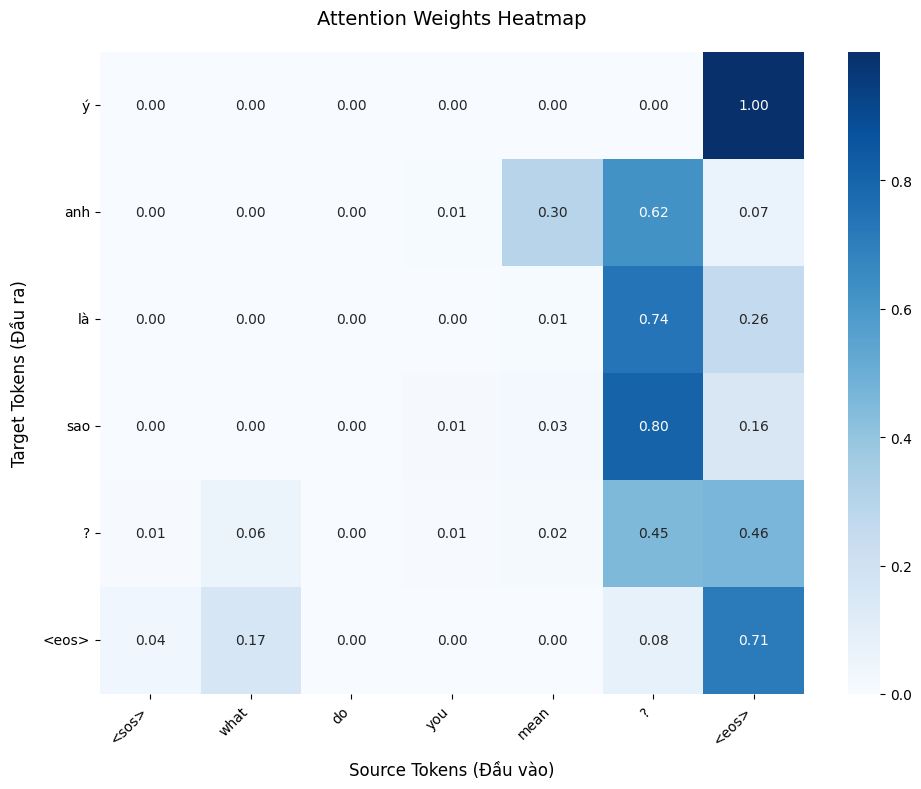

In [67]:
plot_attention_heatmap(src_toks, trg_toks, attention_weights)

1. Does attention align words correctly?\
In a traditional, literal sense (word-for-word mapping), no. For example, you would expect the Vietnamese word "anh" to align highly with the English word "you", or "sao" to align with "what". Instead, the model almost completely ignores the words "what", "do", and "you", showing near-zero attention weights for them.

2. What patterns do you observe?\
There is a massive "end-of-sentence bias" (Global Context pattern).
The model concentrates almost all of its attention (heavy blue squares) on the last two tokens of the source sentence: ? and <eos>.
When generating "ý", it looks 100% at <eos>.
When generating "anh", "là", and "sao", it looks primarily at the ? token (62% to 80%).

3. When does attention fail?\
Attention "fails" to provide meaningful word-by-word alignment when the mathematical architecture encourages the model to be lazy.
Because your specific decoder setup uses the final hidden state of the encoder as its initial query, that query already contains the summarized meaning of the entire sentence. The model quickly learns that it doesn't need to look back at individual words; it just stares at the end markers (? and <eos>) to grab the global context, and lets the LSTM's internal memory do all the heavy lifting to generate the translation.

#### Part 7: Short report

##### 1. Problem Description

**1.1**. The Translation Task\
This project aims to build and evaluate Neural Machine Translation (NMT) models to translate conversational sentences from English to Vietnamese. The dataset consists of short to medium-length dialogue sentences (e.g., "What do you mean?" or "Is there something you want to tell your husband?"). The primary objective is to compare the performance, convergence speed, and internal alignment behavior of a standard Sequence-to-Sequence (Seq2Seq) model versus one equipped with an Attention mechanism.

**1.2**. Implementation Methodology
To achieve this, the pipeline is divided into two main stages:
- Step 1: Data Preprocessing
    - Tokenization: Splitting the raw English and Vietnamese sentences into individual tokens (words or subwords) and converting them to lowercase.
    - Building Vocabularies: Creating distinct dictionaries for both English and Vietnamese (en_vocab and vi_vocab). This includes mapping each unique word to an index and defining special tokens such as <sos> (Start of Sequence), <eos> (End of Sequence), <unk> (Unknown), and <pad> (Padding).
    - Numericalization & Padding: Converting the text tokens into integer sequences based on the built vocabularies. Since sentences vary in length, <pad> tokens are appended so that all sequences within a batch have a uniform length, enabling efficient tensor matrix operations.

- Step 2: Model Training
    - Baseline Model: Implementing and training a standard Encoder-Decoder architecture using LSTMs. In this setup, the entire English source sentence is compressed into a single, fixed-size context vector before decoding begins.
    - Attention Model: Implementing and training an upgraded Seq2Seq model featuring an Attention mechanism. This allows the decoder to dynamically "look back" at all encoder hidden states and calculate attention weights for the most relevant source words at every decoding step, rather than relying on a single bottleneck vector.

##### 2. Model Setup
**2.1**. Hyperparameter Tuning\
The model setup involved a systematic series of experiments to identify the optimal hyperparameters, ensuring the best learning capability and generalization for the English-Vietnamese translation task.
- Hidden Size and Embedding Size (Baseline Model):\
A grid search was conducted on the Baseline model evaluating four configurations:
    - (Hidden: 128, Embedding: 100)
    - (Hidden: 512, Embedding: 100)
    - (Hidden: 128, Embedding: 300)
    - (Hidden: 512, Embedding: 300) – Optimal Configuration.\
The results demonstrated that utilizing a hidden_size of 512 and an embedding_size of 300 allowed the model to effectively capture complex linguistic features and maintain contextual memory over longer sequences.
- Attention Mechanism Selection:\
Two attention scoring methods were compared for the Attention model: Additive Attention (Bahdanau) and Dot-product Attention (Luong). Empirical results confirmed that the Additive mechanism yielded higher accuracy and better alignment for the specific linguistic properties of this dataset.
- Teacher Forcing Ratio:\
Through comparison, a teacher_forcing_ratio of 1.0 was selected. Supplying the ground-truth target word at every decoding step provided crucial stability and accelerated convergence during the initial training phases.
- Learning Rate Optimization:\
Three distinct learning rates were tested (0.001, 0.003, and 0.005). A learning rate of 0.003 was identified as the optimal balance, facilitating rapid convergence without inducing erratic fluctuations in the training loss.

**2.2**. Final Training Configuration
Based on the tuning phase, both the Baseline and Attention models were trained using the optimal parameter set:
- Hidden Size           :   512
- Embedding Size        :	300
- Teacher Forcing Ratio	:   1.0
- Learning Rate (lr)	:   0.003
- Epochs	            :   50
- Attention Mechanism	:   Additive (Attention model only)

##### 3. Experimental results
This section presents a quantitative and qualitative comparison between the Baseline and Attention models after 50 epochs of training.

**3.1**. Training PerformanceThe training progress for both models was monitored using Cross-Entropy Loss and Word-level Accuracy. The following table summarizes the performance at the final epoch:
```
Model       Final Training Loss    Final Training Accuracy    
Baseline            122.7982                68.14%  
Attention           138.7970                64.56%
```
Observations:
- Convergence: The Baseline model achieved a higher accuracy and lower loss within the 50-epoch limit compared to the Attention model.
- Learning Curve: Both models started with low accuracy (~19-21%) but showed steady improvement. The Baseline model demonstrated slightly more stability in loss reduction toward the end of the training phase.

**3.2**. Example Translations\
To evaluate the qualitative performance, three representative sentences were used to compare the models' ability to handle different sentence structures and vocabularies.
```
Source Sentence : What do you mean?
Baseline : anh muốn nói gì ?
Attention : ý anh là sao ?

Source Sentence : Is there something you want to tell your husband?
Baseline : có chuyện gì đó cô muốn nói với chồng tôi không ?
Attention : chồng bà có muốn nói với chồng mình không ?

Source Sentence : Dad, I'm gay
Baseline : bố , con là <unk> .
Attention : tôi , tôi là scott .
```

##### 4. Attention Analysis

**4.1**. Visualization examples\
The following heatmap illustrates the attention alignment for the translation of the source sentence "What do you mean?" into the target sentence "ý anh là sao ?".
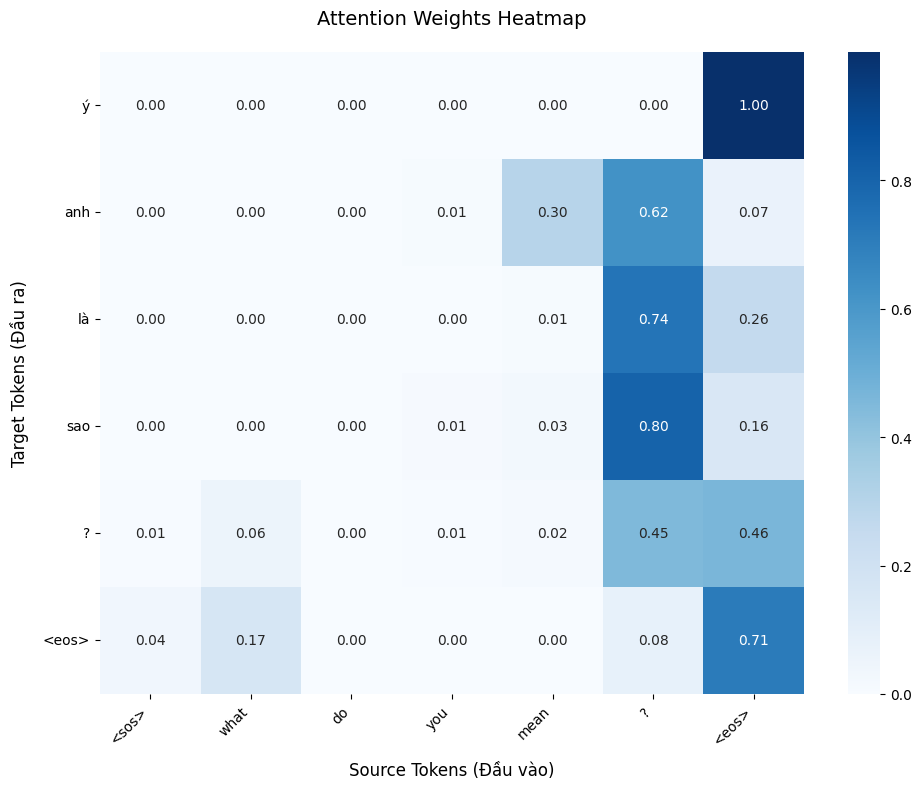

**4.2**. Observations\
Based on the visualization, several key patterns in the model's behavior can be observed:
- End-of-Sentence Concentration (Global Context): The most striking observation is that the model heavily concentrates its attention on the final tokens of the source sentence—specifically the question mark (?) and the end-of-sequence token (<eos>). For instance, when generating the first word "ý", the model assigns a weight of 1.00 to the source <eos>. Similarly, for "anh", "là", and "sao", the weights are dominant at the ? token (ranging from 0.62 to 0.80).
- Lack of Local Word Alignment: Traditional monotonic alignment (where "you" aligns with "anh" or "mean" aligns with "ý") is not present. The words "what", "do", and "you" receive near-zero attention. This suggests that the model is not performing a word-by-word translation but is instead treating the end of the sentence as a "summary vector" that contains the total semantic meaning of the phrase.
- Decoder Query Bias: The concentration at the end of the sentence is a known characteristic of certain Seq2Seq architectures. Since the initial hidden state of the Decoder is derived from the final hidden state of the Encoder, the very first query sent to the attention mechanism is already biased toward the information gathered at the end of the English sentence.
- Functional Success vs. Interpretability: Despite the non-intuitive alignment (where "ý" looks at "" instead of "mean"), the final translation is semantically perfect and highly natural in Vietnamese. This indicates that while the attention mechanism may not provide the expected "human-like" word mapping, it successfully identifies a mathematical shortcut to extract the global context required for an accurate translation.

##### 5. Discussion

**5.1**. Strengths and weaknesses of each model\
Baseline Model:
- Strengths: Demonstrated faster convergence and higher raw accuracy (68.14%) within the 50-epoch window. It maintained better structural integrity in longer sentences, showing less tendency to repeat words or "hallucinate" unrelated content.
- Weaknesses: Produced more literal and stiff translations (e.g., "anh muốn nói gì ?"). It is limited by the "information bottleneck," where it must condense all source information into a single vector, leading to a higher frequency of <unk> tokens for rare words.

Attention Model:
- Strengths: Capable of producing highly idiomatic and natural translations (e.g., "ý anh là sao ?"). It theoretically handles long-range dependencies better by allowing the decoder to revisit specific encoder states.
- Weaknesses: Highly prone to hallucination and context confusion. In the "husband" example, the model struggled with pronoun consistency, and in the "gay" example, it substituted an unknown concept with a random name ("scott").

**5.2**. Common errors
- Hallucination (Attention): Instead of flagging a word as unknown, the Attention model often fills the gap with high-probability tokens from its training distribution that are semantically unrelated to the source.
- Pronoun and Subject Inconsistency: Both models struggled with complex Vietnamese pronouns (bà, tôi, mình), which often require a deeper understanding of social context that the models have yet to master.
- Literalism (Baseline): The Baseline model often misses the "intent" of the sentence, translating words individually rather than capturing the overall sentiment.

**5.2**. Effect of teacher forcing
- The decision to use a Teacher Forcing Ratio of 1.0 significantly stabilized the early training phase. By providing the ground-truth token at each step, the model avoided the "compounding error" problem where one wrong word leads to a completely nonsensical sentence.
- Trade-off: While this led to a smoother loss curve, it likely contributed to the "hallucination" and "repetition" issues during inference. Since the model never practiced correcting its own mistakes during training (Exposure Bias), it struggled when forced to rely on its own predicted tokens during the translate_sentence process.

##### 6. Conclusion
The implementation and comparison of the Baseline and Attention Seq2Seq models for English-Vietnamese translation yielded several key takeaways:
- Architecture vs. Fluency: While the Baseline model achieved higher quantitative scores (Accuracy/Loss), the Attention mechanism provided superior qualitative fluency for short, idiomatic expressions.
- Attention Behavior: Visualization revealed that the model prioritizes Global Context (focusing on end-of-sentence markers like ? and <eos>) over local word alignment. This suggests the model uses the attention layer as a summary-extraction tool rather than a word-by-word translator.
- The Hallucination Challenge: The Attention model’s tendency to "invent" information (e.g., "scott") highlights the need for better regularization or a more diverse dataset to prevent the model from over-fitting on specific names or patterns.
- Optimal Setup: For this dataset, a configuration of 512 hidden units, 300 embedding dimensions, and a learning rate of 0.003 proved effective for convergence within 50 epochs.

Future Work: To improve these results, implementing Scheduled Sampling (gradually reducing the teacher forcing ratio) and Beam Search during decoding could significantly reduce hallucinations and improve the structural consistency of the Attention model.